# Classificazione cardiovascolare

## Obiettivo e caricamento del dataset

**Obiettivo principale.** Sviluppare e valutare un modello di classificazione binaria capace di distinguere i soggetti classificati nel dataset come affetti da patologia cardiovascolare (`cardio = 1`) da quelli non affetti (`cardio = 0`), utilizzando le variabili cliniche, antropometriche e comportamentali disponibili.

La metrica principale è l'accuracy, per massimizzare la quota di record classificati correttamente assegnando lo stesso peso ai due tipi di errore. Le altre metriche completano la valutazione.


### Librerie e impostazioni

In [1]:
from pathlib import Path
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import chi2_contingency, mannwhitneyu, t as student_t
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import gc
import textwrap
import random
from collections import defaultdict
from time import perf_counter

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.layers import Dense, Dropout, Input
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l2

except ImportError:
    tf = None
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix,
    f1_score, log_loss, precision_score,
    recall_score, roc_auc_score, roc_curve,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import (
    GridSearchCV, GroupShuffleSplit, ParameterGrid, StratifiedGroupKFold, cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if tf is not None:
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

TARGET_COL = "cardio"

RAW_PREDICTOR_COLUMNS = [
    "age", "gender", "height", "weight", "ap_hi", "ap_lo",
    "cholesterol", "gluc", "smoke", "alco", "active",
]

PALETTE = {0: "#2A6F97", 1: "#D1495B"}
TARGET_LABELS = {0: "Cardio = 0", 1: "Cardio = 1"}
ACCENT = "#2A9D8F"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titleweight": "bold",
    "figure.dpi": 110,
})

def show_table(frame, caption=None, precision=3):
    styler = frame.style.format(precision=precision)
    if caption:
        styler = styler.set_caption(caption)
    return display(styler)

PLAUSIBILITY_LIMITS = {
    "age_years": (18, 100), "height": (120, 220),
    "weight": (30, 250), "ap_hi": (70, 250),
    "ap_lo": (40, 150), "bmi": (10, 70),
}
ALLOWED_CATEGORIES = {
    "gender": (0, 1), "cholesterol": (0, 1, 2), "gluc": (0, 1, 2),
    "smoke": (0, 1), "alco": (0, 1), "active": (0, 1),
}
PRESSURE_COLUMNS = ["ap_hi", "ap_lo"]

def outside_limits(values, name):
    return ~values.between(*PLAUSIBILITY_LIMITS[name])

ANTHROPOMETRIC_COLUMNS = ["height", "weight"]

def calculate_bmi(frame):
    return frame["weight"] / (frame["height"] / 100) ** 2




### Caricamento e validazione dello schema



In [2]:
DATASET_FILE = "health_data.csv"
DATASET_HANDLE = "akshatshaw7/cardiovascular-disease-dataset"

dataset_path = Path(DATASET_FILE)

if dataset_path.is_file():
    csv_path = dataset_path
    data_source = f"file locale: {csv_path.resolve()}"

else:
    try:
        dataset_dir = Path(
            kagglehub.dataset_download(DATASET_HANDLE)
        )

        csv_files = sorted(dataset_dir.rglob("*.csv"))

        if len(csv_files) != 1:
            raise ValueError(
                f"Atteso un solo CSV; trovati: {csv_files}"
            )

        csv_path = csv_files[0]
        data_source = "Kaggle"

    except Exception as kaggle_error:
        try:
            from google.colab import files
        except ImportError:
            raise FileNotFoundError(
                f"Il file '{DATASET_FILE}' non è presente nella "
                "cartella di lavoro e il download da Kaggle "
                "non è riuscito."
            ) from kaggle_error

        print(
            f"Download da Kaggle non riuscito: {kaggle_error}\n"
            f"Selezionare il file '{DATASET_FILE}'."
        )

        uploaded = files.upload()

        if DATASET_FILE not in uploaded:
            raise FileNotFoundError(
                f"Il file deve chiamarsi '{DATASET_FILE}'."
            )

        csv_path = Path(DATASET_FILE)
        data_source = "upload manuale Colab"

df_raw = pd.read_csv(
    csv_path,
    encoding="utf-8-sig",
    sep=None,
    engine="python",
)

expected_columns = [
    "Unnamed: 0", "id", "age", "gender", "height", "weight",
    "ap_hi", "ap_lo", "cholesterol", "gluc", "smoke", "alco",
    "active", "cardio",
]

missing_columns = set(expected_columns).difference(df_raw.columns)

if missing_columns:
    raise ValueError(
        "Il dataset non contiene le colonne richieste: "
        f"{sorted(missing_columns)}"
    )

if (
    df_raw["cardio"].isna().any()
    or set(df_raw["cardio"].unique()) != {0, 1}
):
    raise ValueError(
        "cardio deve contenere entrambe le classi 0 e 1, "
        "senza valori mancanti."
    )

print(f"Dataset caricato da: {data_source}")
print(
    f"Dimensioni: {df_raw.shape[0]:,} righe, "
    f"{df_raw.shape[1]} colonne"
)

display(df_raw.head())


100%|██████████| 998k/998k [00:00<00:00, 24.5MB/s]

Extracting files...


Dataset caricato da: Kaggle
Dimensioni: 70,000 righe, 14 colonne


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.000,"18,393.000",1,168.000,62.000,110.000,80.000,0,0,0,0,1,0
1,1,1.000,"20,228.000",0,156.000,85.000,140.000,90.000,2,0,0,0,1,1
2,2,2.000,"18,857.000",0,165.000,64.000,130.000,70.000,2,0,0,0,0,1
3,3,3.000,"17,623.000",1,169.000,82.000,150.000,100.000,0,0,0,0,1,1
4,4,4.000,"17,474.000",0,156.000,56.000,100.000,60.000,0,0,0,0,0,0


In [3]:
structure = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "non_nulli": df_raw.notna().sum(),
    "n_unici": df_raw.nunique(dropna=False),
    "esempio": [
        df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else np.nan
        for c in df_raw
    ],
})
show_table(structure, "Struttura del dataset")


,dtype,non_nulli,n_unici,esempio
Unnamed: 0,int64,70000,70000,0.000
id,float64,70000,70000,0.000
age,float64,70000,8076,18393.000
gender,int64,70000,2,1.000
height,float64,70000,109,168.000
weight,float64,70000,287,62.000
ap_hi,float64,70000,153,110.000
ap_lo,float64,70000,157,80.000
cholesterol,int64,70000,3,0.000
gluc,int64,70000,3,0.000


## Analisi esplorativa dei dati

I controlli preliminari di qualità, completezza, duplicazione e plausibilità riguardano l’intero dataset. Dopo lo split per profilo predittivo, le distribuzioni e le associazioni con il target sono analizzate soltanto sul training set.


### Preparazione delle variabili

In [4]:
df = df_raw.drop(columns=["Unnamed: 0", "id"]).copy()
df["age_years"] = df["age"] / 365.25
df["bmi"] = df["weight"] / (df["height"] / 100) ** 2
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["mean_arterial_pressure"] = (df["ap_hi"] + 2 * df["ap_lo"]) / 3

continuous_cols = [
    "age_years", "height", "weight", "bmi",
    "ap_hi", "ap_lo", "pulse_pressure", "mean_arterial_pressure"
]
categorical_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

df_typed = df.copy()
for col in categorical_cols + [TARGET_COL]:
    df_typed[col] = df_typed[col].astype("category")

print(f"Dati per i controlli preliminari: {df.shape[0]:,} righe × {df.shape[1]} colonne")
display(df.head())
display(
    df_typed.dtypes.rename("dtype").to_frame()
    .style.set_caption("Tipologia di dati")
)
df_all = df.copy()


Dati per i controlli preliminari: 70,000 righe × 16 colonne


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,mean_arterial_pressure
0,"18,393.000",1,168.000,62.000,110.000,80.000,0,0,0,0,1,0,50.357,21.967,30.000,90.000
1,"20,228.000",0,156.000,85.000,140.000,90.000,2,0,0,0,1,1,55.381,34.928,50.000,106.667
2,"18,857.000",0,165.000,64.000,130.000,70.000,2,0,0,0,0,1,51.628,23.508,60.000,90.000
3,"17,623.000",1,169.000,82.000,150.000,100.000,0,0,0,0,1,1,48.249,28.710,50.000,116.667
4,"17,474.000",0,156.000,56.000,100.000,60.000,0,0,0,0,0,0,47.841,23.011,40.000,73.333


,dtype
age,float64
gender,category
height,float64
weight,float64
ap_hi,float64
ap_lo,float64
cholesterol,category
gluc,category
smoke,category
alco,category


### Qualità, completezza e coerenza

In [5]:
quality_summary = pd.DataFrame({
    "n_mancanti": df_raw.isna().sum(),
    "perc_mancanti": df_raw.isna().mean().mul(100),
    "n_infiniti": [np.isinf(df_raw[c]).sum() if pd.api.types.is_numeric_dtype(df_raw[c]) else 0 for c in df_raw],
    "n_unici": df_raw.nunique(dropna=False),
})
display(quality_summary.style.format({"perc_mancanti": "{:.2f}%"}).set_caption("completezza"))

duplicates = pd.Series({
    "righe duplicate complete": int(df_raw.duplicated().sum()),
    "ID duplicati": int(df_raw["id"].duplicated().sum()),
    "duplicati ignorando gli identificatori": int(df_raw.drop(columns=["Unnamed: 0", "id"]).duplicated().sum()),
}, name="conteggio")
display(duplicates.to_frame())

allowed_values = {**ALLOWED_CATEGORIES, TARGET_COL: (0, 1)}
domain_check = pd.DataFrame([
    {"variabile": col, "valori_osservati": sorted(df_raw[col].dropna().unique().tolist()),
     "n_fuori_dominio": int((~df_raw[col].isin(valid)).sum())}
    for col, valid in allowed_values.items()
]).set_index("variabile")
display(domain_check)

,n_mancanti,perc_mancanti,n_infiniti,n_unici
Unnamed: 0,0,0.00%,0,70000
id,0,0.00%,0,70000
age,0,0.00%,0,8076
gender,0,0.00%,0,2
height,0,0.00%,0,109
weight,0,0.00%,0,287
ap_hi,0,0.00%,0,153
ap_lo,0,0.00%,0,157
cholesterol,0,0.00%,0,3
gluc,0,0.00%,0,3


,conteggio
righe duplicate complete,0
ID duplicati,0
duplicati ignorando gli identificatori,24


,valori_osservati,n_fuori_dominio
variabile,,
gender,"[0, 1]",0
cholesterol,"[0, 1, 2]",0
gluc,"[0, 1, 2]",0
smoke,"[0, 1]",0
alco,"[0, 1]",0
active,"[0, 1]",0
cardio,"[0, 1]",0


### Profili predittivi ripetuti e target discordanti

In [6]:
profiles = df_raw[RAW_PREDICTOR_COLUMNS + [TARGET_COL]].copy()

profile_target_audit = (
    profiles
    .groupby(RAW_PREDICTOR_COLUMNS, dropna=False)[TARGET_COL]
    .agg(
        n_record="size",
        n_target_distinti="nunique",
        n_target_mancanti=lambda s: s.isna().sum(),
    )
    .reset_index()
)

repeated_profiles = profile_target_audit["n_record"] > 1
discordant_profiles = profile_target_audit["n_target_distinti"] > 1

profile_summary = pd.Series({
    "record nel dataset": len(profiles),
    "profili predittivi unici": len(profile_target_audit),
    "record ripetuti oltre la prima occorrenza": len(profiles) - len(profile_target_audit),
    "profili presenti più volte": repeated_profiles.sum(),
    "record appartenenti a profili ripetuti": profile_target_audit.loc[repeated_profiles, "n_record"].sum(),
    "profili con target discordante": discordant_profiles.sum(),
    "record in profili con target discordante": profile_target_audit.loc[discordant_profiles, "n_record"].sum(),
}, name="conteggio").astype(int)
display(profile_summary.to_frame())

,conteggio
record nel dataset,70000
profili predittivi unici,69959
record ripetuti oltre la prima occorrenza,41
profili presenti più volte,41
record appartenenti a profili ripetuti,82
profili con target discordante,17
record in profili con target discordante,34


In [7]:
plausibility_flags = pd.DataFrame(index=df_all.index)
plausibility_flags["eta_fuori_limiti"] = outside_limits(df_all["age_years"], "age_years")
plausibility_flags["altezza_fuori_limiti"] = outside_limits(df_all["height"], "height")
plausibility_flags["peso_fuori_limiti"] = outside_limits(df_all["weight"], "weight")
plausibility_flags["sistolica_fuori_limiti"] = outside_limits(df_all["ap_hi"], "ap_hi")
plausibility_flags["diastolica_fuori_limiti"] = outside_limits(df_all["ap_lo"], "ap_lo")
plausibility_flags["sistolica_non_superiore"] = df_all["ap_hi"] <= df_all["ap_lo"]
plausibility_flags["bmi_fuori_limiti"] = outside_limits(df_all["bmi"], "bmi")
plausibility_flags["almeno_un_flag"] = plausibility_flags.any(axis=1)

plausibility_summary = pd.DataFrame({
    "n": plausibility_flags.sum(),
    "percentuale": plausibility_flags.mean().mul(100),
}).sort_values("n", ascending=False)
display(plausibility_summary.style.format({"percentuale": "{:.2f}%"}).set_caption("Segnalazioni di plausibilità"))

display(df_all.loc[plausibility_flags["almeno_un_flag"], continuous_cols + [TARGET_COL]].head(15))
plausibility_flags_all = plausibility_flags.copy()


,n,percentuale
almeno_un_flag,1393,1.99%
sistolica_non_superiore,1236,1.77%
diastolica_fuori_limiti,1034,1.48%
sistolica_fuori_limiti,229,0.33%
altezza_fuori_limiti,53,0.08%
bmi_fuori_limiti,42,0.06%
peso_fuori_limiti,7,0.01%
eta_fuori_limiti,0,0.00%


,age_years,height,weight,bmi,ap_hi,ap_lo,pulse_pressure,mean_arterial_pressure,cardio
224,59.685,76.000,55.000,95.222,120.000,80.000,40.000,93.333,0
228,47.882,183.000,98.000,29.263,160.000,"1,100.000",-940.000,786.667,1
241,60.047,157.000,60.000,24.342,160.000,"1,000.000",-840.000,720.000,1
260,49.875,150.000,83.000,36.889,140.000,800.000,-660.000,580.000,1
329,64.085,176.000,63.000,20.338,160.000,"1,000.000",-840.000,720.000,1
345,51.209,154.000,81.000,34.154,140.000,"1,000.000",-860.000,713.333,1
418,45.607,157.000,72.000,29.210,150.000,30.000,120.000,70.000,1
473,41.687,150.000,95.000,42.222,150.000,"1,033.000",-883.000,738.667,1
474,52.290,156.000,65.000,26.709,120.000,150.000,-30.000,140.000,0
559,55.934,173.000,101.000,33.747,200.000,"1,000.000",-800.000,733.333,1


### Isolamento di training, validation e test


In [8]:
X_raw = df_raw.drop(columns=TARGET_COL).copy()
y = df_raw[TARGET_COL]
y = y.astype("int8")

profile_groups = pd.util.hash_pandas_object(
    df_raw[RAW_PREDICTOR_COLUMNS], index=False
)

train_idx, temporary_idx = next(
    GroupShuffleSplit(
        n_splits=1, test_size=0.30, random_state=RANDOM_STATE
    ).split(X_raw, groups=profile_groups)
)

validation_relative_idx, test_relative_idx = next(
    GroupShuffleSplit(
        n_splits=1, test_size=0.50, random_state=RANDOM_STATE + 1
    ).split(
        X_raw.iloc[temporary_idx],
        groups=profile_groups.iloc[temporary_idx],
    )
)

validation_idx = temporary_idx[validation_relative_idx]
test_idx = temporary_idx[test_relative_idx]

indices = [train_idx, validation_idx, test_idx]

X_train, X_validation, X_test = [X_raw.iloc[i].copy() for i in indices]
y_train, y_validation, y_test = [y.iloc[i].copy() for i in indices]
groups_train, groups_validation, groups_test = [
    profile_groups.iloc[i].copy() for i in indices
]

split_summary = pd.DataFrame([
    {
        "insieme": name,
        "n": len(i),
        "percentuale": len(i) / len(y),
        "cardio_1": y.iloc[i].mean(),
        "gruppi_unici": profile_groups.iloc[i].nunique(),
    }
    for name, i in zip(["training", "validation", "test"], indices)
])

display(
    split_summary.style.format({
        "percentuale": "{:.2%}",
        "cardio_1": "{:.2%}",
    })
)

df = df_all.loc[X_train.index].copy()
plausibility_flags = plausibility_flags_all.loc[X_train.index].copy()
df_typed = df.copy()
for col in categorical_cols + [TARGET_COL]:
    df_typed[col] = df_typed[col].astype("category")

assert df.index.equals(X_train.index)
assert plausibility_flags.index.equals(df.index)
assert df[TARGET_COL].equals(y_train.astype(df[TARGET_COL].dtype))
print(f"Dati per l'EDA successiva allo split: {len(df):,} record del training set")


,insieme,n,percentuale,cardio_1,gruppi_unici
0,training,48999,70.00%,50.00%,48971
1,validation,10500,15.00%,49.56%,10494
2,test,10501,15.00%,50.23%,10494


Dati per l'EDA successiva allo split: 48,999 record del training set


### Analisi univariata

#### Variabili continue

In [9]:
desc = df[continuous_cols].describe(percentiles=[.005, .01, .25, .5, .75, .99, .995]).T
desc["IQR"] = desc["75%"] - desc["25%"]
desc["asimmetria"] = df[continuous_cols].skew()
display(desc[["count", "mean", "std", "min", "0.5%", "1%", "25%", "50%", "75%", "99%", "99.5%", "max", "IQR", "asimmetria"]])

,count,mean,std,min,0.5%,1%,25%,50%,75%,99%,99.5%,max,IQR,asimmetria
age_years,"48,999.000",53.299,6.744,29.563,39.441,39.611,48.361,53.941,58.371,64.304,64.455,64.890,10.010,-0.306
height,"48,999.000",164.329,8.228,55.000,144.000,147.000,159.000,165.000,170.000,184.000,186.000,207.000,11.000,-0.733
weight,"48,999.000",74.206,14.339,10.000,45.000,48.000,65.000,72.000,82.000,117.000,125.000,200.000,17.000,1.002
bmi,"48,999.000",27.578,6.234,3.673,17.836,18.671,23.875,26.370,30.323,44.366,47.805,298.667,6.448,8.671
ap_hi,"48,999.000",128.982,156.418,-140.000,90.000,90.000,120.000,120.000,140.000,180.000,190.000,"14,020.000",20.000,80.565
ap_lo,"48,999.000",97.078,194.868,-70.000,60.000,60.000,80.000,80.000,90.000,"1,000.000","1,000.000","11,000.000",10.000,31.525
pulse_pressure,"48,999.000",31.904,247.980,"-10,800.000",-860.000,-840.000,40.000,40.000,50.000,85.000,90.000,"13,940.000",10.000,5.101
mean_arterial_pressure,"48,999.000",107.713,140.734,-41.667,70.000,70.000,93.333,93.333,103.333,716.667,723.333,"7,400.000",10.000,28.969


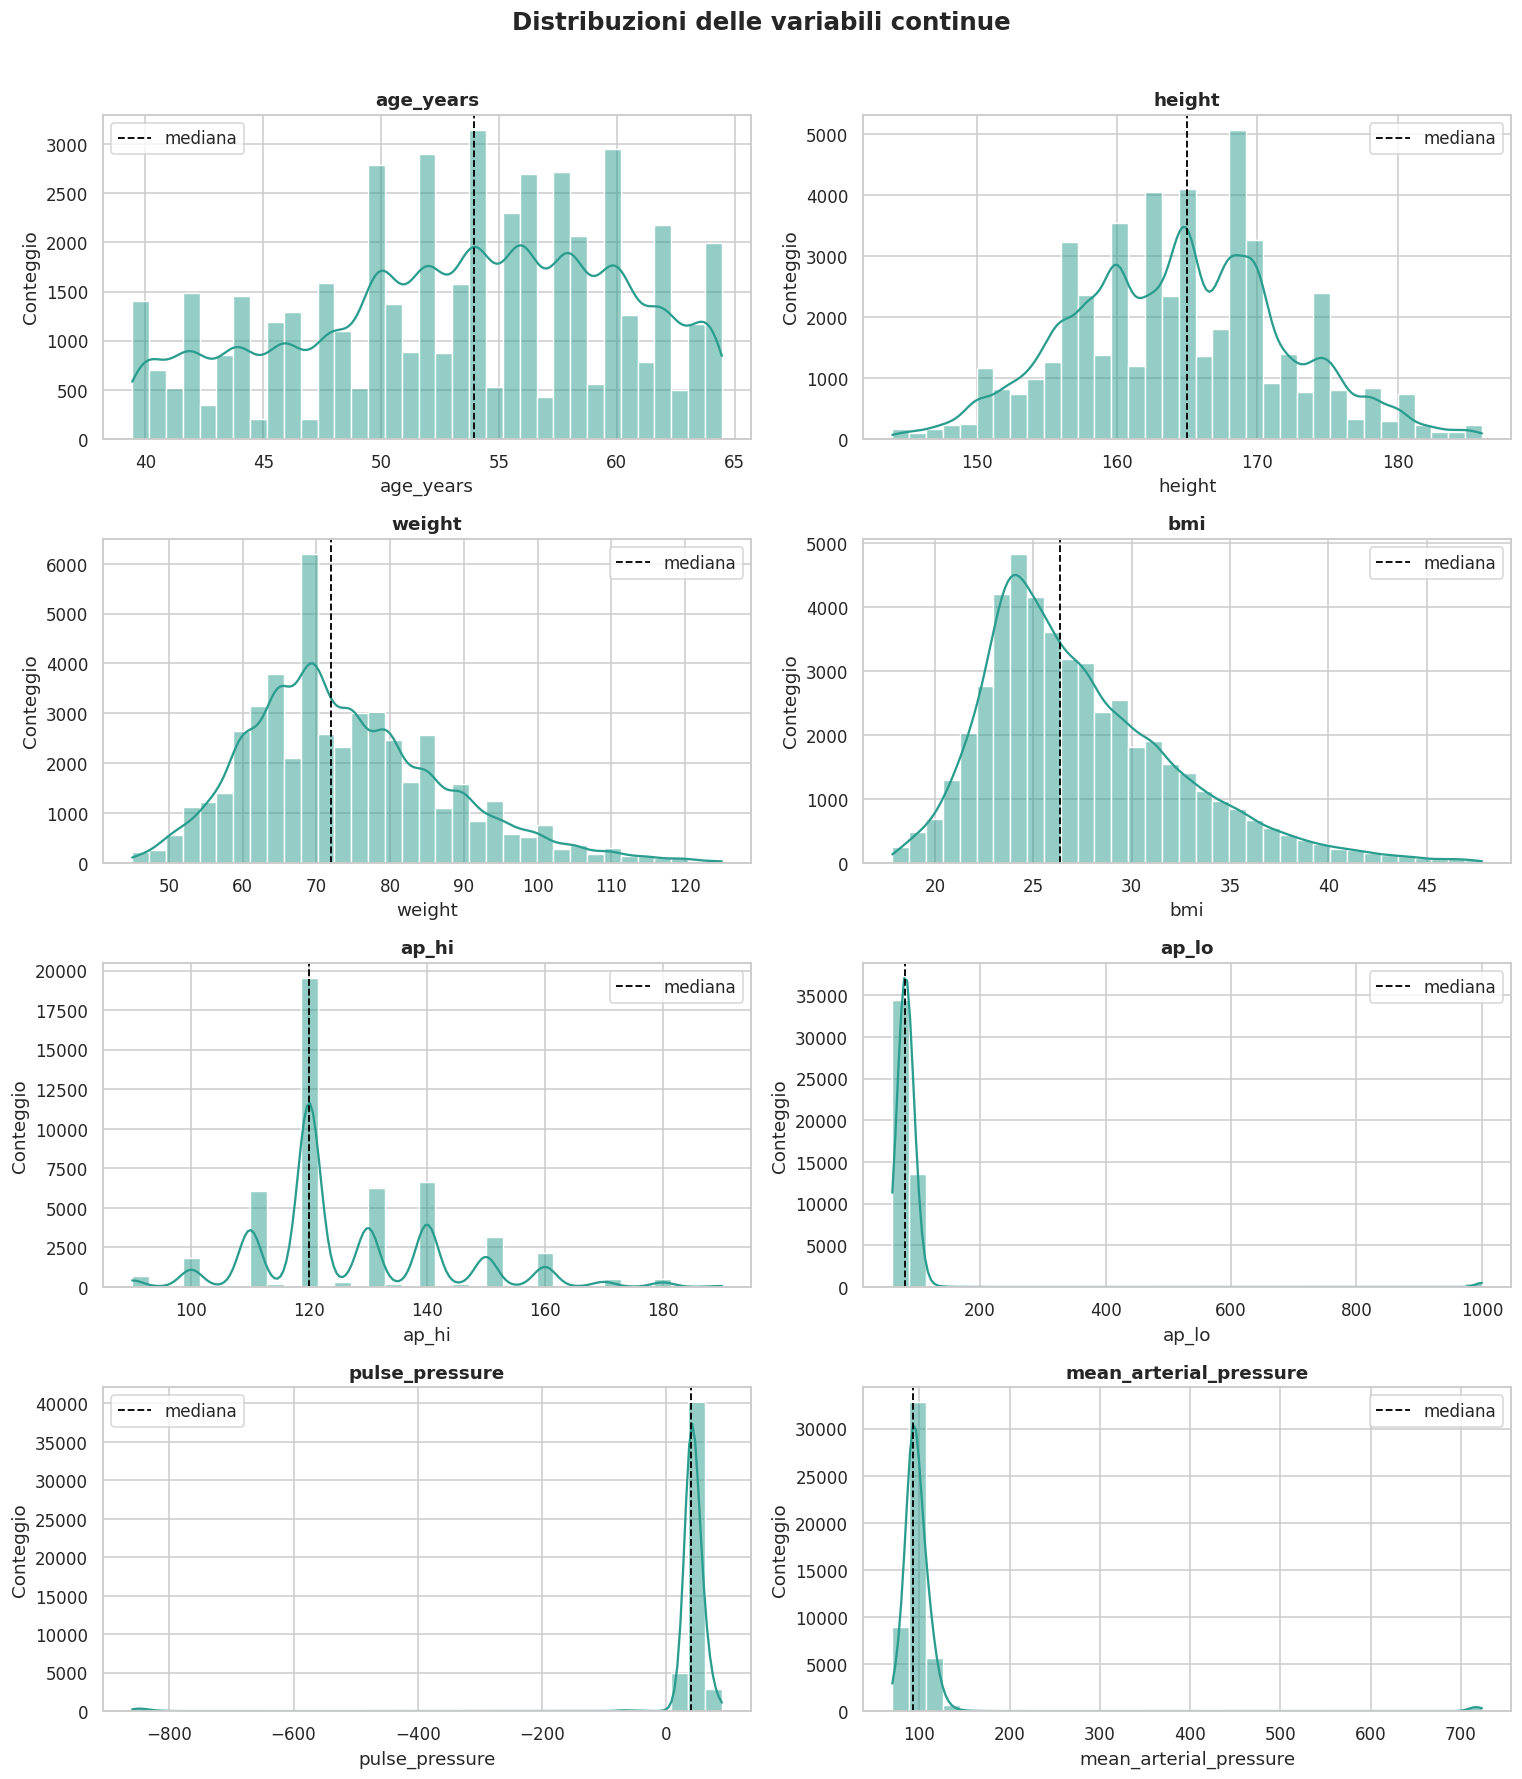

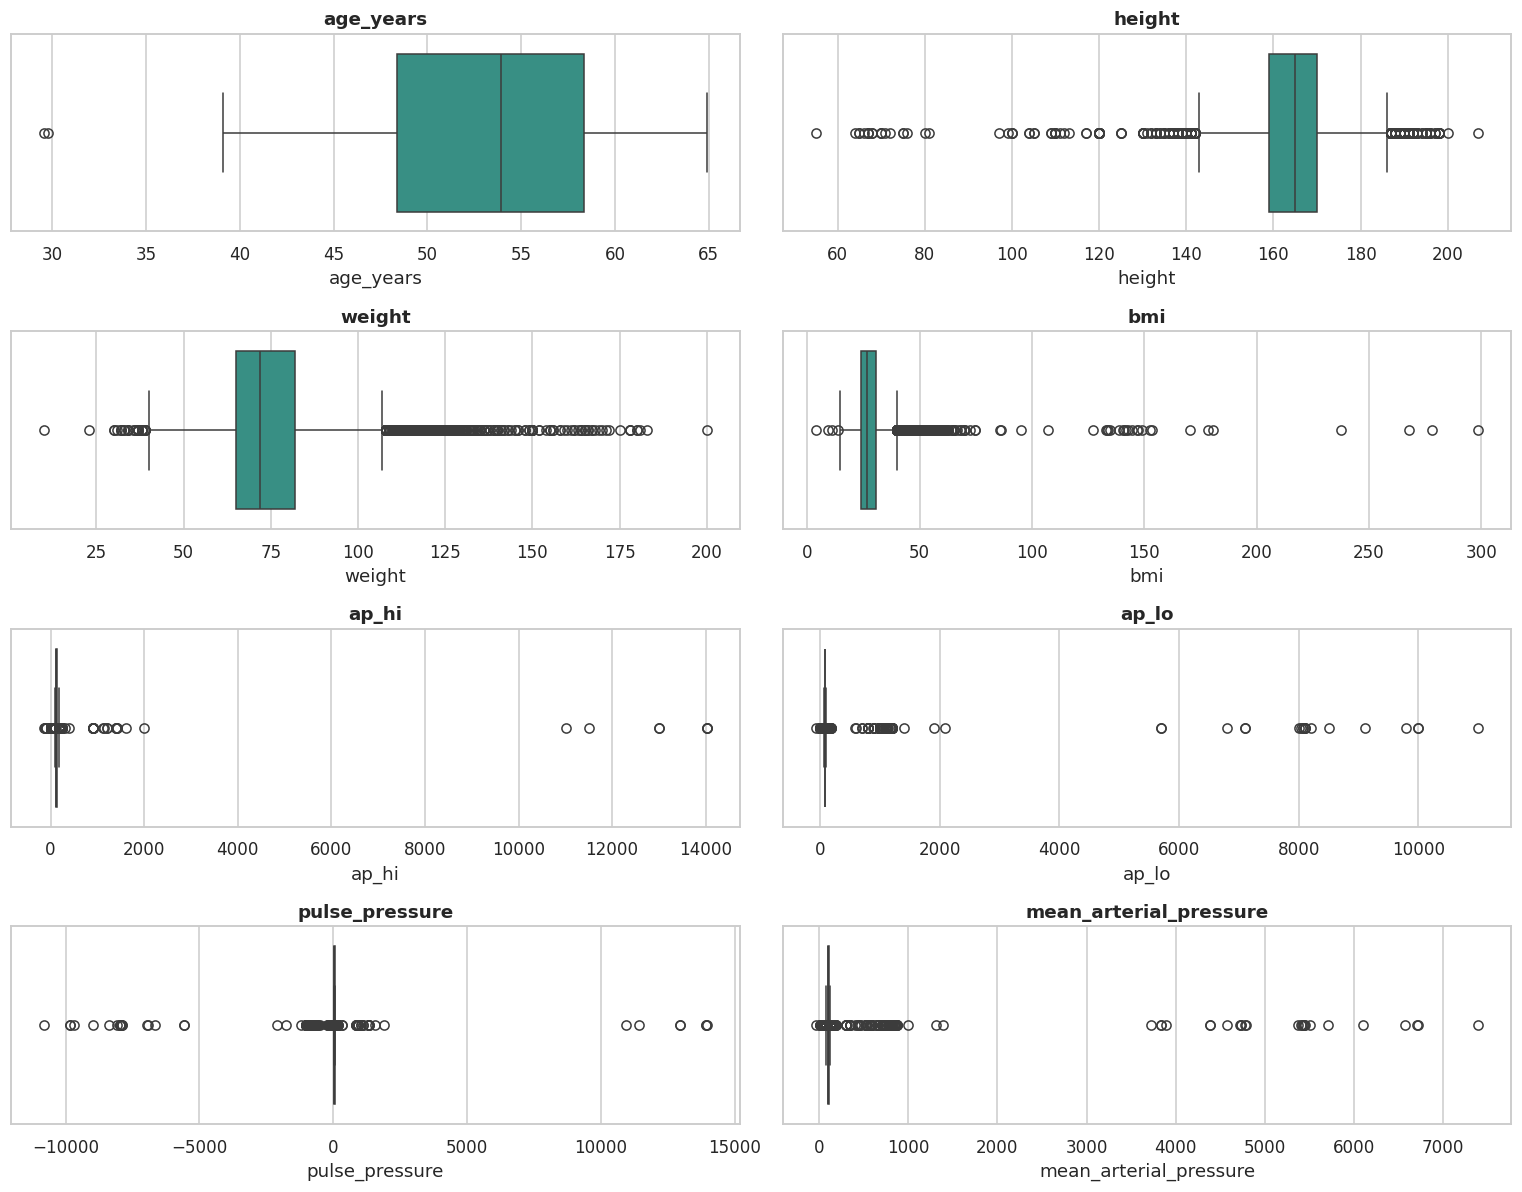

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flat, continuous_cols):
    lo, hi = df[col].quantile([.005, .995])
    sns.histplot(df.loc[df[col].between(lo, hi), col], bins=35, kde=True, color=ACCENT, ax=ax)
    ax.axvline(df[col].median(), color="black", ls="--", lw=1.2, label="mediana")
    ax.set(title=f"{col}", ylabel="Conteggio")
    ax.legend()
plt.suptitle("Distribuzioni delle variabili continue", y=1.01, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 11))
for ax, col in zip(axes.flat, continuous_cols):
    sns.boxplot(x=df[col], color=ACCENT, showfliers=True, ax=ax)
    ax.set_title(f"{col}")
plt.tight_layout()
plt.show()

#### Variabili categoriche

,variabile,livello,n,percentuale
0,gender,0,31945,65.20%
1,gender,1,17054,34.80%
2,cholesterol,0,36644,74.79%
3,cholesterol,1,6696,13.67%
4,cholesterol,2,5659,11.55%
5,gluc,0,41591,84.88%
6,gluc,1,3609,7.37%
7,gluc,2,3799,7.75%
8,smoke,0,44727,91.28%
9,smoke,1,4272,8.72%


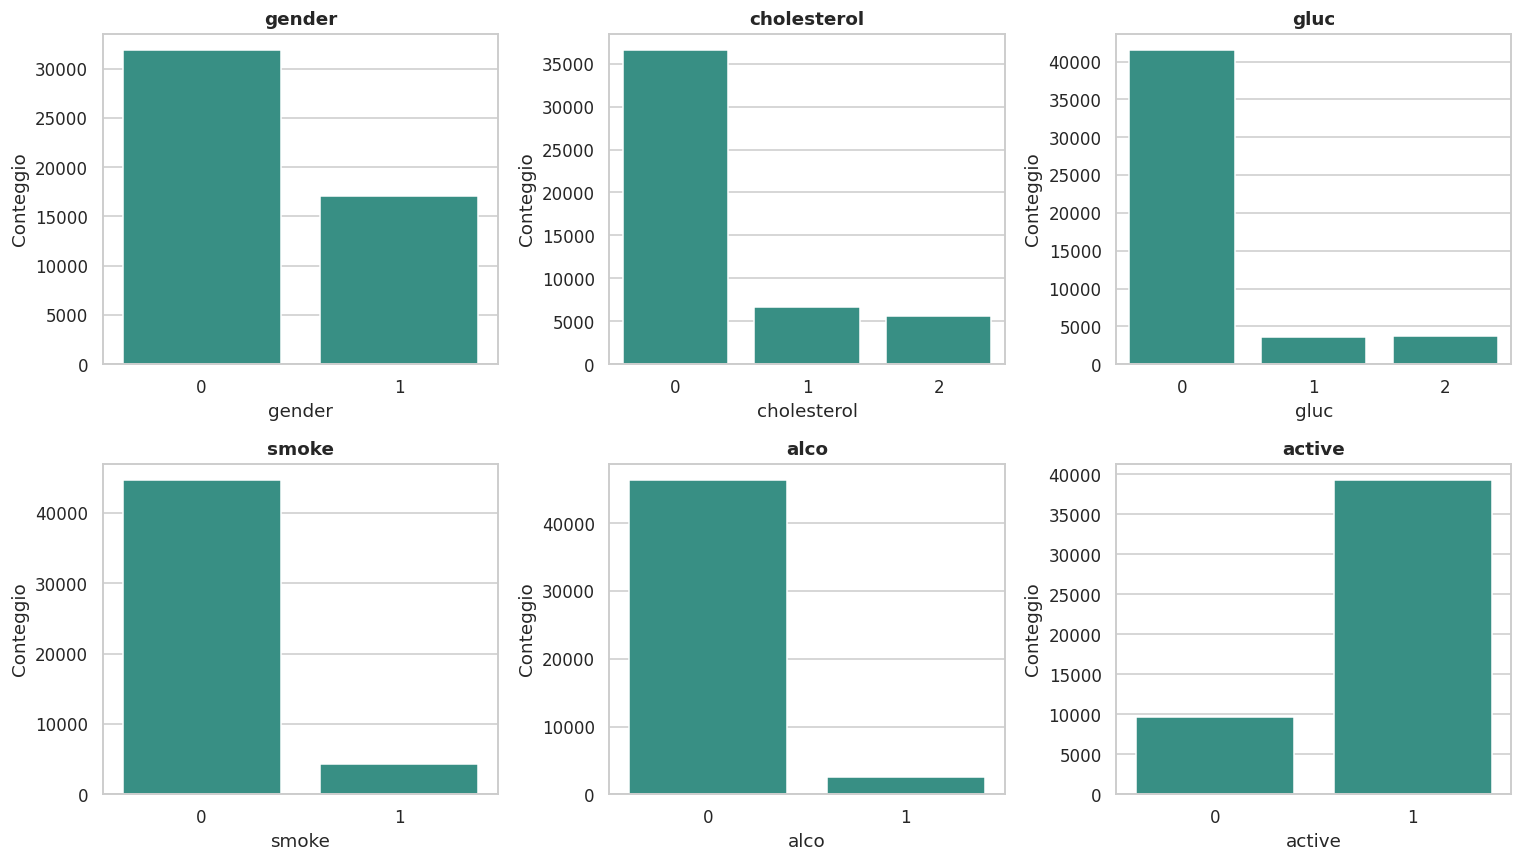

In [11]:
frequency_tables = []
for col in categorical_cols:
    tab = df[col].value_counts(dropna=False).sort_index().rename_axis("livello").reset_index(name="n")
    tab["percentuale"] = 100 * tab["n"] / len(df)
    tab.insert(0, "variabile", col)
    frequency_tables.append(tab)
frequency_table = pd.concat(frequency_tables, ignore_index=True)
display(frequency_table.style.format({"percentuale": "{:.2f}%"}).set_caption("Distribuzioni delle variabili categoriche"))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, categorical_cols):
    order = sorted(df[col].dropna().unique())
    sns.countplot(data=df, x=col, order=order, color=ACCENT, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("Conteggio")
plt.tight_layout()
plt.show()

### Distribuzione del target

,n,percentuale
cardio,,
0,24499,50.00%
1,24500,50.00%


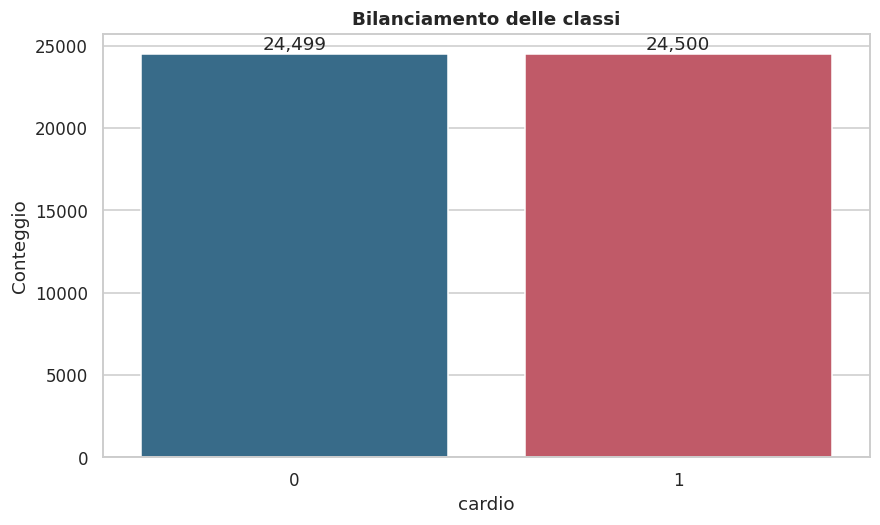

In [12]:
target_summary = df[TARGET_COL].value_counts().sort_index().rename_axis(TARGET_COL).to_frame("n")
target_summary["percentuale"] = target_summary["n"] / len(df) * 100
display(target_summary.style.format({"percentuale": "{:.2f}%"}).set_caption("Distribuzione del target"))

ax = sns.countplot(data=df, x=TARGET_COL, hue=TARGET_COL, palette=PALETTE, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
ax.set(title="Bilanciamento delle classi", xlabel="cardio", ylabel="Conteggio")
plt.show()

### Variabili continue rispetto al target

In [13]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = np.minimum.accumulate((ranked * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted

numeric_rows = []
for col in continuous_cols:
    x0 = df.loc[df[TARGET_COL] == 0, col].dropna()
    x1 = df.loc[df[TARGET_COL] == 1, col].dropna()
    u_stat, p_value = mannwhitneyu(x1, x0, alternative="two-sided")
    numeric_rows.append({
        "variabile": col, "mediana_cardio_0": x0.median(), "mediana_cardio_1": x1.median(),
        "differenza_mediane": x1.median() - x0.median(),
        "IQR_cardio_0": x0.quantile(.75) - x0.quantile(.25),
        "IQR_cardio_1": x1.quantile(.75) - x1.quantile(.25),
        "rank_biserial": 2 * u_stat / (len(x1) * len(x0)) - 1,
        "p_value": p_value,
    })

numeric_association = pd.DataFrame(numeric_rows)
numeric_association["p_adj_BH"] = benjamini_hochberg(numeric_association["p_value"])
numeric_association["forza_effetto"] = pd.cut(
    numeric_association["rank_biserial"].abs(), bins=[-np.inf, .1, .3, .5, np.inf],
    labels=["trascurabile", "piccolo", "moderato", "grande"]
)
display(numeric_association.sort_values("rank_biserial", key=abs, ascending=False).style.format({"p_value": "{:.2e}", "p_adj_BH": "{:.2e}"}))

,variabile,mediana_cardio_0,mediana_cardio_1,differenza_mediane,IQR_cardio_0,IQR_cardio_1,rank_biserial,p_value,p_adj_BH,forza_effetto
4,ap_hi,120.000000,130.000000,10.000000,10.000000,20.000000,0.506090,0.00e+00,0.00e+00,grande
7,mean_arterial_pressure,93.333333,100.000000,6.666667,6.666667,13.333333,0.491578,0.00e+00,0.00e+00,moderato
5,ap_lo,80.000000,80.000000,0.000000,10.000000,10.000000,0.389015,0.00e+00,0.00e+00,moderato
6,pulse_pressure,40.000000,50.000000,10.000000,0.000000,20.000000,0.354673,0.00e+00,0.00e+00,moderato
0,age_years,52.021903,55.813826,3.791923,11.045859,9.613279,0.273755,0.00e+00,0.00e+00,piccolo
3,bmi,25.476660,27.471698,1.995038,5.452845,7.107470,0.228898,0.00e+00,0.00e+00,piccolo
2,weight,70.000000,75.000000,5.000000,16.000000,19.000000,0.210893,0.00e+00,0.00e+00,piccolo
1,height,165.000000,164.000000,-1.000000,11.000000,11.000000,-0.016925,1.16e-03,1.16e-03,trascurabile


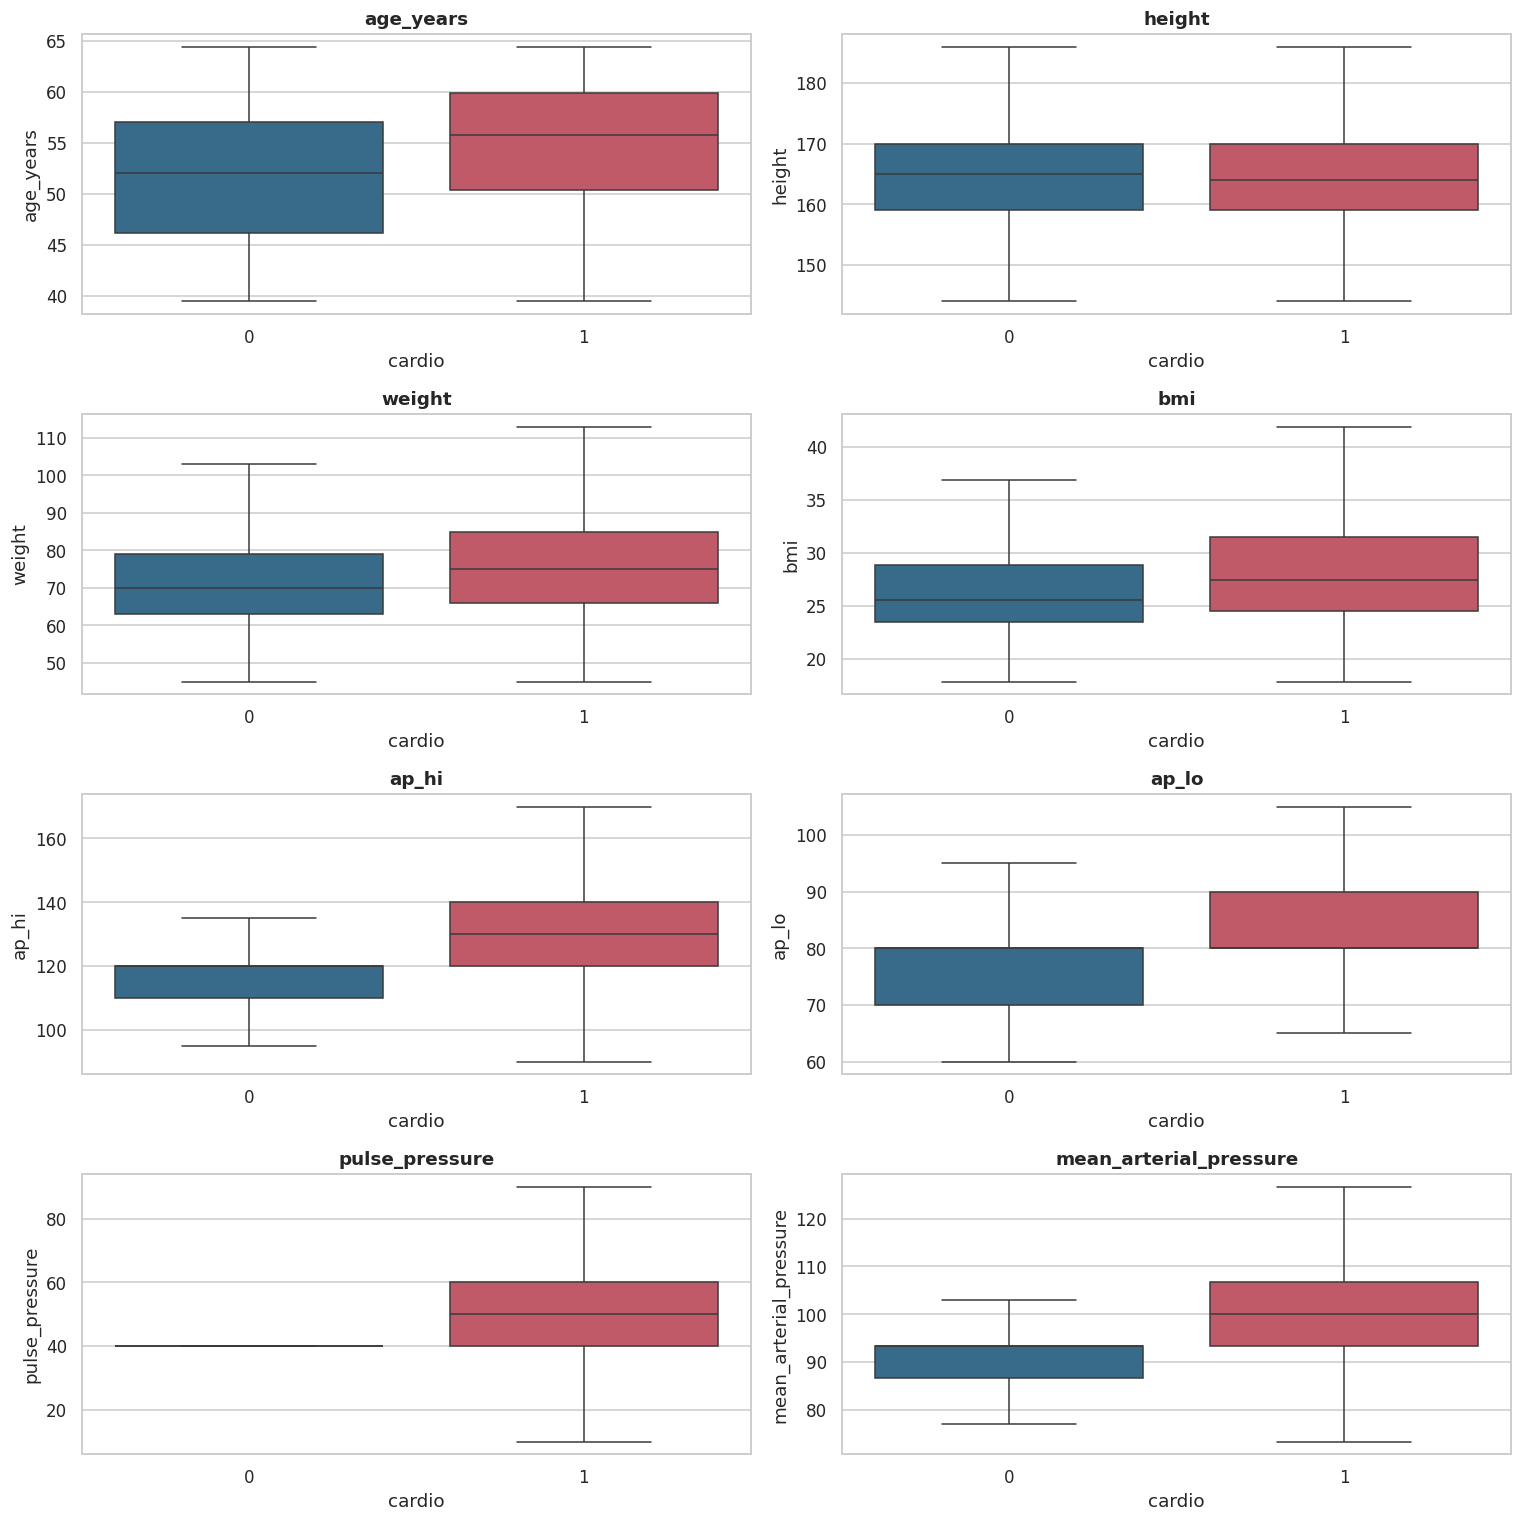

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for ax, col in zip(axes.flat, continuous_cols):
    plot_df = df[df[col].between(df[col].quantile(.005), df[col].quantile(.995))]
    sns.boxplot(data=plot_df, x=TARGET_COL, y=col, hue=TARGET_COL, palette=PALETTE,
                showfliers=False, legend=False, ax=ax)
    ax.set_title(f"{col}")
plt.tight_layout()
plt.show()

### Variabili categoriche rispetto al target

In [15]:
def wilson_interval(successes, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    proportion = successes / n
    denominator = 1 + z**2 / n
    center = (proportion + z**2 / (2 * n)) / denominator
    margin = (
        z
        * np.sqrt(proportion * (1 - proportion) / n + z**2 / (4 * n**2))
        / denominator
    )
    return center - margin, center + margin


def calculate_prevalence(df, col, target):
    grouped = (
        df.groupby(col, dropna=False)[target]
        .agg(n="size", casi="sum", prevalenza="mean")
        .reset_index()
    )

    intervals = grouped.apply(
        lambda row: wilson_interval(row["casi"], row["n"]),
        axis=1,
    )
    grouped[["ci95_low", "ci95_high"]] = pd.DataFrame(
        intervals.tolist(), index=grouped.index
    )

    for name in ["prevalenza", "ci95_low", "ci95_high"]:
        grouped[f"{name}_pct"] = grouped[name] * 100

    grouped.insert(0, "variabile", col)
    return grouped


def calculate_association(df, col, target):
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_value, _, _ = chi2_contingency(contingency, correction=False)

    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt((chi2 / n) / min_dim) if min_dim > 0 else np.nan

    return {
        "variabile": col,
        "chi2": chi2,
        "p_value": p_value,
        "cramers_v": cramers_v,
    }


prevalence_tables = []
association_results = []

for col in categorical_cols:
    prevalence_tables.append(calculate_prevalence(df, col, TARGET_COL))
    association_results.append(calculate_association(df, col, TARGET_COL))

categorical_prevalence = pd.concat(prevalence_tables, ignore_index=True)
categorical_tests = pd.DataFrame(association_results)

categorical_tests["p_adj_BH"] = benjamini_hochberg(
    categorical_tests["p_value"]
)
categorical_tests["forza_associazione"] = pd.cut(
    categorical_tests["cramers_v"],
    bins=[-np.inf, 0.1, 0.3, 0.5, np.inf],
    labels=["trascurabile", "piccola", "moderata", "grande"],
)

prevalence_columns = ["prevalenza", "ci95_low", "ci95_high"]
prevalence_format = {
    name: "{:.3f}" for name in prevalence_columns
}
prevalence_format.update({
    f"{name}_pct": "{:.2f}%" for name in prevalence_columns
})

display(categorical_prevalence.style.format(prevalence_format))
display(
    categorical_tests
    .sort_values("cramers_v", ascending=False)
    .style.format({"p_value": "{:.2e}", "p_adj_BH": "{:.2e}"})
)

,variabile,gender,n,casi,prevalenza,ci95_low,ci95_high,prevalenza_pct,ci95_low_pct,ci95_high_pct,cholesterol,gluc,smoke,alco,active
0,gender,0.000000,31945,15893,0.498,0.492,0.503,49.75%,49.20%,50.30%,nan,nan,nan,nan,nan
1,gender,1.000000,17054,8607,0.505,0.497,0.512,50.47%,49.72%,51.22%,nan,nan,nan,nan,nan
2,cholesterol,nan,36644,16173,0.441,0.436,0.446,44.14%,43.63%,44.64%,0.000000,nan,nan,nan,nan
3,cholesterol,nan,6696,4010,0.599,0.587,0.611,59.89%,58.71%,61.05%,1.000000,nan,nan,nan,nan
4,cholesterol,nan,5659,4317,0.763,0.752,0.774,76.29%,75.16%,77.38%,2.000000,nan,nan,nan,nan
5,gluc,nan,41591,20015,0.481,0.476,0.486,48.12%,47.64%,48.60%,nan,0.000000,nan,nan,nan
6,gluc,nan,3609,2148,0.595,0.579,0.611,59.52%,57.91%,61.11%,nan,1.000000,nan,nan,nan
7,gluc,nan,3799,2337,0.615,0.600,0.631,61.52%,59.96%,63.05%,nan,2.000000,nan,nan,nan
8,smoke,nan,44727,22468,0.502,0.498,0.507,50.23%,49.77%,50.70%,nan,nan,0.000000,nan,nan
9,smoke,nan,4272,2032,0.476,0.461,0.491,47.57%,46.07%,49.06%,nan,nan,1.000000,nan,nan


,variabile,chi2,p_value,cramers_v,p_adj_BH,forza_associazione
1,cholesterol,2329.900853,0.00e+00,0.218060,0.00e+00,piccola
2,gluc,390.896538,1.31e-85,0.089318,3.94e-85,trascurabile
5,active,50.080167,1.48e-12,0.031970,2.95e-12,trascurabile
3,smoke,11.103934,8.61e-04,0.015054,1.29e-03,trascurabile
4,alco,4.015714,4.51e-02,0.009053,5.41e-02,trascurabile
0,gender,2.292485,1.30e-01,0.006840,1.30e-01,trascurabile


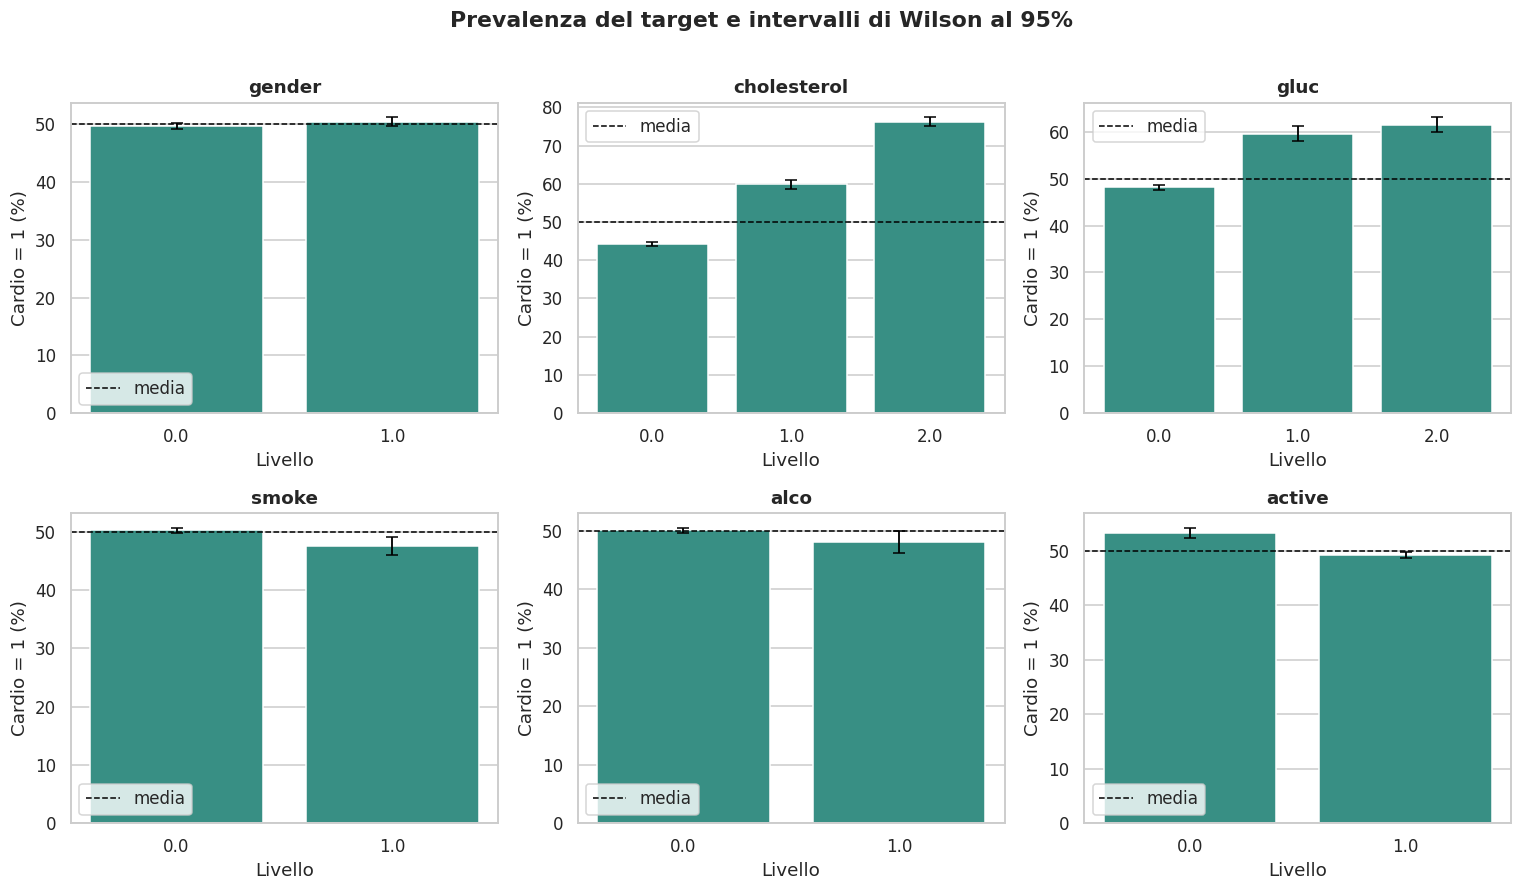

In [16]:
def plot_prevalence(ax, data, col, mean_pct):
    plot_data = (
        data.loc[data["variabile"] == col]
        .sort_values(col)
    )
    prevalence = plot_data["prevalenza_pct"]
    errors = np.vstack([
        prevalence - plot_data["ci95_low_pct"],
        plot_data["ci95_high_pct"] - prevalence,
    ])

    sns.barplot(
        data=plot_data,
        x=col,
        y="prevalenza_pct",
        order=plot_data[col].tolist(),
        color=ACCENT,
        ax=ax,
    )
    ax.errorbar(
        np.arange(len(plot_data)),
        prevalence,
        yerr=errors,
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=4,
    )
    ax.axhline(
        mean_pct, color="black", ls="--", lw=1, label="media"
    )
    ax.set(title=col, ylabel="Cardio = 1 (%)", xlabel="Livello")
    ax.legend()


mean_pct = df[TARGET_COL].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, categorical_cols):
    plot_prevalence(ax, categorical_prevalence, col, mean_pct)

fig.suptitle(
    "Prevalenza del target e intervalli di Wilson al 95%",
    y=1.01,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Correlazioni

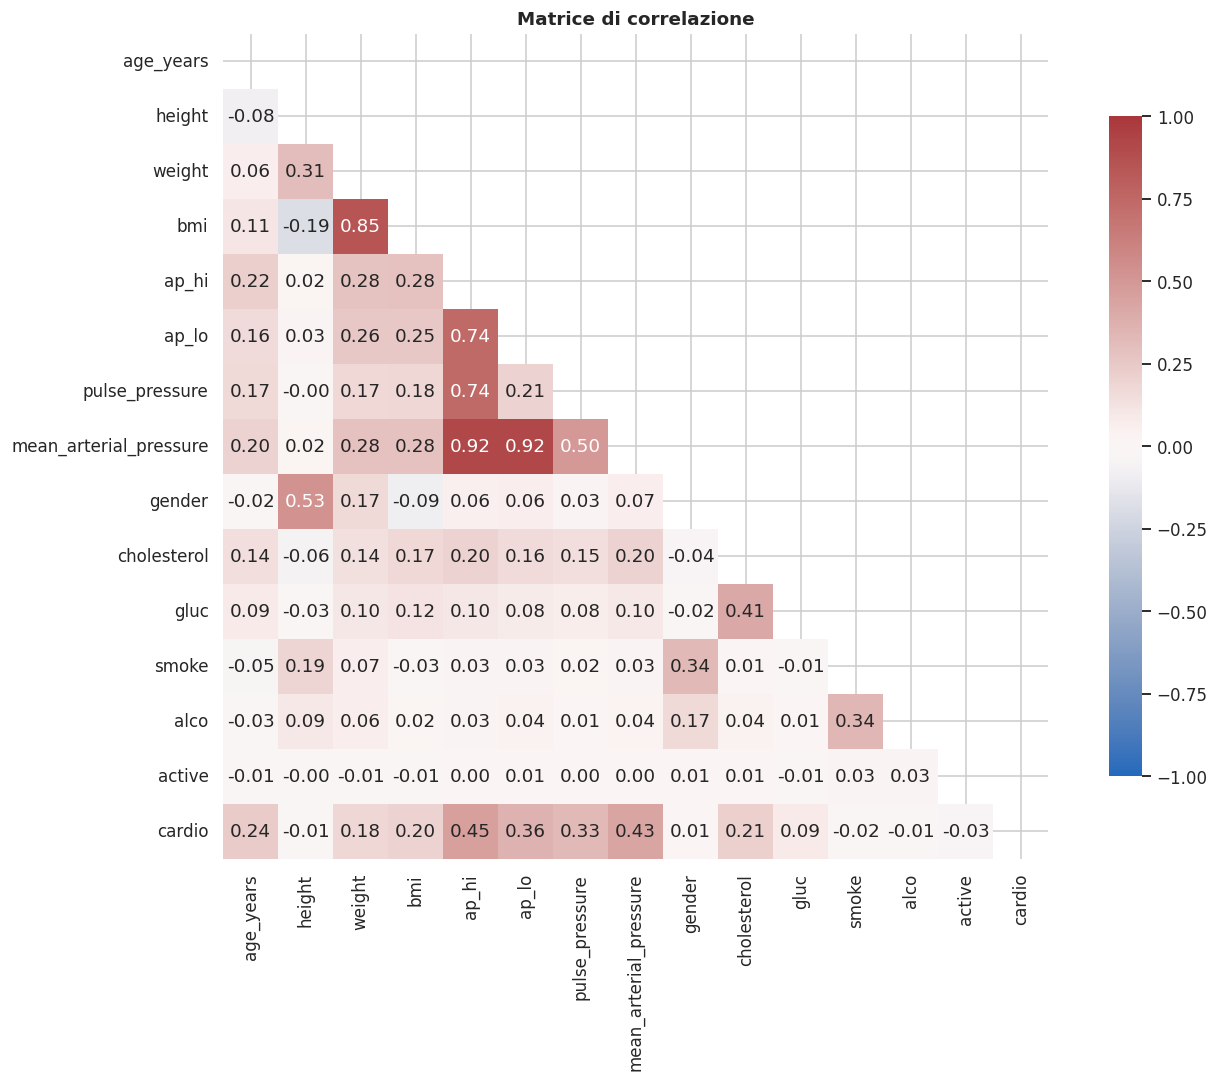

,rho_Spearman_con_cardio
ap_hi,0.454
mean_arterial_pressure,0.435
ap_lo,0.362
pulse_pressure,0.329
age_years,0.237
cholesterol,0.212
bmi,0.198
weight,0.183
gluc,0.089
active,-0.032


In [17]:
def plot_correlation_matrix(corr):
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(13, 10))
    sns.heatmap(
        corr,
        mask=mask,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        square=True,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Matrice di correlazione")
    plt.tight_layout()
    plt.show()


corr_cols = continuous_cols + categorical_cols + [TARGET_COL]
spearman_corr = df[corr_cols].corr(method="spearman")

plot_correlation_matrix(spearman_corr)

target_corr = (
    spearman_corr[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
    .to_frame("rho_Spearman_con_cardio")
)
display(target_corr)

### Analisi multivariata

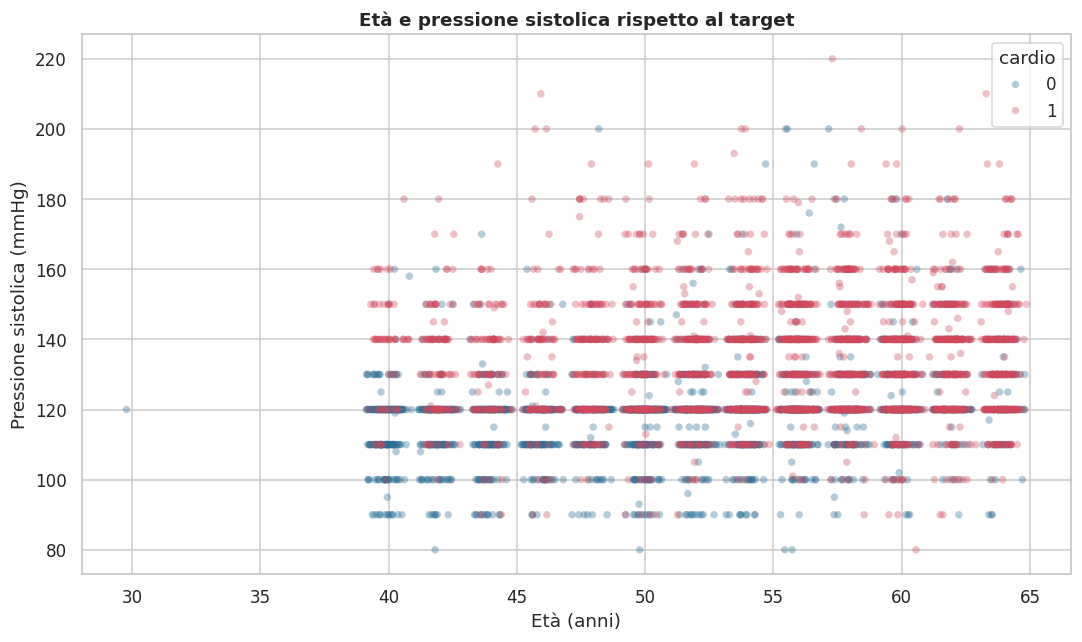

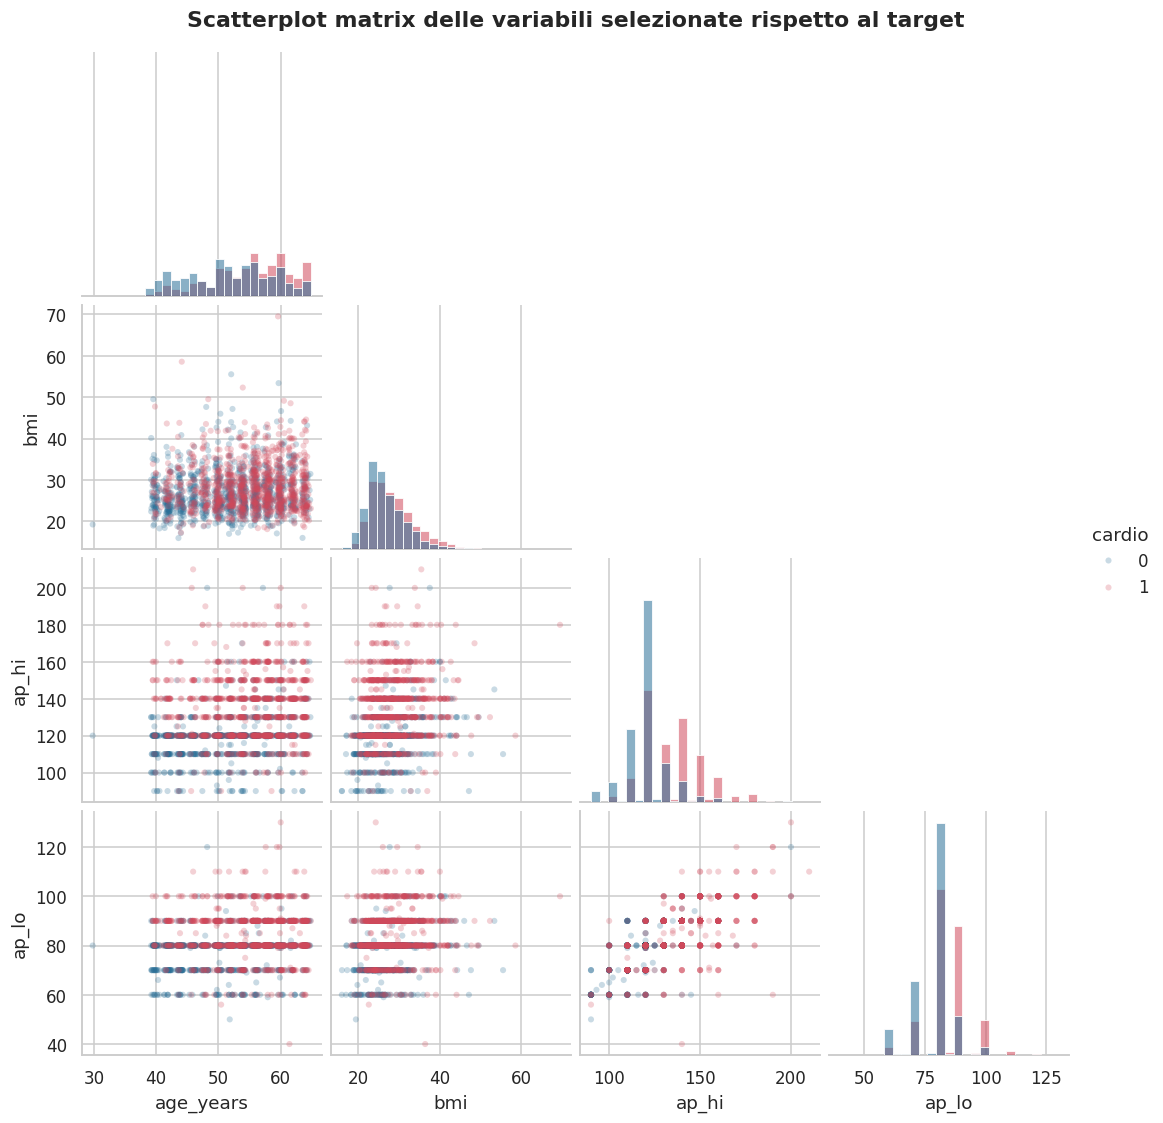

In [18]:
def sample_per_class(data, target, max_per_class, random_state):
    grouped = data.groupby(target, group_keys=False)
    n = min(max_per_class, int(grouped.size().min()))
    return grouped.sample(n=n, random_state=random_state)

visual_base = df.loc[~plausibility_flags["almeno_un_flag"]].copy()

scatter_df = sample_per_class(
    visual_base, TARGET_COL, 3000, RANDOM_STATE
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_df,
    x="age_years",
    y="ap_hi",
    hue=TARGET_COL,
    palette=PALETTE,
    alpha=0.35,
    s=24,
    linewidth=0,
)
plt.title("Età e pressione sistolica rispetto al target")
plt.xlabel("Età (anni)")
plt.ylabel("Pressione sistolica (mmHg)")
plt.legend(title="cardio")
plt.tight_layout()
plt.show()

pairplot_vars = ["age_years", "bmi", "ap_hi", "ap_lo"]
pairplot_cols = pairplot_vars + [TARGET_COL]
pairplot_df = sample_per_class(
    visual_base[pairplot_cols], TARGET_COL, 1000, RANDOM_STATE
)

g = sns.pairplot(
    pairplot_df,
    vars=pairplot_vars,
    hue=TARGET_COL,
    palette=PALETTE,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.25, "s": 16, "linewidth": 0},
    diag_kws={"alpha": 0.55, "bins": 25},
)
g.fig.suptitle(
    "Scatterplot matrix delle variabili selezionate rispetto al target",
    y=1.02,
    fontweight="bold",
)
plt.show()

### Gradienti di rischio descrittivi e interazioni

,n,prevalenza,prevalenza_pct
age_group,,,
<40,1271,0.227,22.66%
40–49,13644,0.374,37.42%
50–59,24413,0.513,51.34%
≥60,8703,0.672,67.20%


,n,prevalenza,prevalenza_pct
bmi_group,,,
<18.5,431,0.281,28.07%
18.5–24.9,17866,0.399,39.86%
25–29.9,17088,0.505,50.53%
≥30,12646,0.624,62.45%


,n,prevalenza,prevalenza_pct
bp_group,,,
120–139 o 80–89,24976,0.378,37.77%
<120/<80,6642,0.224,22.42%
≥140 o ≥90,16413,0.783,78.30%


bp_group,120–139 o 80–89,<120/<80,≥140 o ≥90
age_group,,,
<40,663,374,234
40–49,7178,2857,3609
50–59,12953,2736,8724
≥60,4182,675,3846


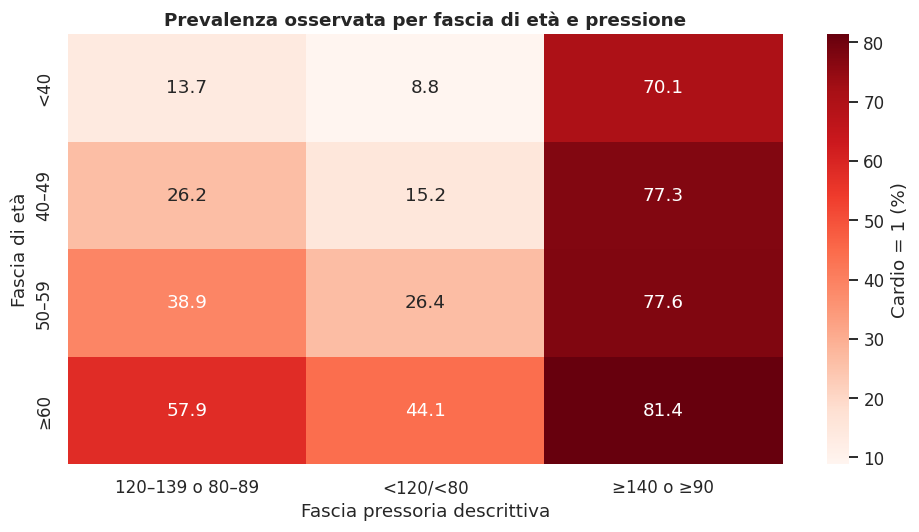

In [19]:
df_bands = df.loc[~plausibility_flags["almeno_un_flag"]].copy()

band_definitions = {
    "age_group": (
        "age_years",
        [0, 40, 50, 60, np.inf],
        ["<40", "40–49", "50–59", "≥60"],
    ),
    "bmi_group": (
        "bmi",
        [0, 18.5, 25, 30, np.inf],
        ["<18.5", "18.5–24.9", "25–29.9", "≥30"],
    ),
}

for group, (source, bins, labels) in band_definitions.items():
    df_bands[group] = pd.cut(
        df_bands[source], bins=bins, labels=labels, right=False
    )

systolic = df_bands["ap_hi"]
diastolic = df_bands["ap_lo"]

df_bands["bp_group"] = np.select(
    [
        (systolic < 120) & (diastolic < 80),
        (systolic < 140) & (diastolic < 90),
        (systolic >= 140) | (diastolic >= 90),
    ],
    ["<120/<80", "120–139 o 80–89", "≥140 o ≥90"],
    default="non classificabile",
)

for col in ["age_group", "bmi_group", "bp_group"]:
    table = (
        df_bands.groupby(col, observed=True)[TARGET_COL]
        .agg(n="size", prevalenza="mean")
        .assign(prevalenza_pct=lambda data: data["prevalenza"] * 100)
    )
    display(
        table.style
        .format({"prevalenza": "{:.3f}", "prevalenza_pct": "{:.2f}%"})
        .set_caption(f"Prevalenza per {col}")
    )

age_bp_n = pd.crosstab(
    df_bands["age_group"], df_bands["bp_group"]
)
age_bp_prev = df_bands.pivot_table(
    index="age_group",
    columns="bp_group",
    values=TARGET_COL,
    aggfunc="mean",
    observed=True,
) * 100

display(
    age_bp_n.style.set_caption("Numerosità delle celle età × pressione")
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    age_bp_prev,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Cardio = 1 (%)"},
)
plt.title("Prevalenza osservata per fascia di età e pressione")
plt.xlabel("Fascia pressoria descrittiva")
plt.ylabel("Fascia di età")
plt.tight_layout()
plt.show()

### Analisi di sensibilità ai valori non plausibili

In [20]:
def target_spearman(data, features, target):
    return (
        data[features + [target]]
        .corr(method="spearman")[target]
        .loc[features]
    )

flagged = plausibility_flags["almeno_un_flag"]
df_plausible = df.loc[~flagged].copy()
n_total = len(df)

sensitivity_summary = pd.DataFrame({
    "campione": [
        "training completo",
        "training: solo record plausibili",
        "training: record segnalati",
    ],
    "n": [
        n_total,
        len(df_plausible),
        flagged.sum(),
    ],
    "percentuale_del_totale": [
        100,
        len(df_plausible) / n_total * 100,
        flagged.mean() * 100,
    ],
    "prevalenza_cardio_pct": [
        df[TARGET_COL].mean() * 100,
        df_plausible[TARGET_COL].mean() * 100,
        df.loc[flagged, TARGET_COL].mean() * 100,
    ],
})

display(
    sensitivity_summary.style.format({
        "percentuale_del_totale": "{:.2f}%",
        "prevalenza_cardio_pct": "{:.2f}%",
    })
)

key_correlation_features = ["ap_hi", "ap_lo", "bmi", "age_years"]

correlation_sensitivity = pd.DataFrame({
    "rho_training_completo": target_spearman(
        df, key_correlation_features, TARGET_COL
    ),
    "rho_training_plausibile": target_spearman(
        df_plausible, key_correlation_features, TARGET_COL
    ),
})
correlation_sensitivity["differenza_assoluta"] = (
    correlation_sensitivity["rho_training_plausibile"]
    - correlation_sensitivity["rho_training_completo"]
).abs()

display(
    correlation_sensitivity
    .sort_values("rho_training_completo", key=abs, ascending=False)
    .style.format("{:.3f}")
    .set_caption("Sensibilità delle correlazioni di Spearman con cardio")
)

,campione,n,percentuale_del_totale,prevalenza_cardio_pct
0,training completo,48999,100.00%,50.00%
1,training: solo record plausibili,48031,98.02%,49.50%
2,training: record segnalati,968,1.98%,75.00%


,rho_training_completo,rho_training_plausibile,differenza_assoluta
ap_hi,0.454,0.454,0.000
ap_lo,0.362,0.356,0.006
age_years,0.237,0.239,0.002
bmi,0.198,0.197,0.001


## Preprocessing

In [21]:
from sklearn.utils.validation import check_is_fitted

NUMERIC_FEATURES = ["age_years", "height", "weight", "ap_hi", "ap_lo", "bmi"]
BINARY_FEATURES = ["gender", "smoke", "alco", "active"]
ORDINAL_FEATURES = ["cholesterol", "gluc"]
MODEL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + ORDINAL_FEATURES


class FeatureCleaner(TransformerMixin, BaseEstimator):

    def __init__(self, limits=None):
        self.limits = limits

    def _check_schema(self, X):
        if not X.columns.is_unique:
            raise ValueError("Nomi di colonna duplicati.")
        missing = sorted(set(RAW_PREDICTOR_COLUMNS) - set(X.columns))
        if missing:
            raise ValueError(f"Predittori mancanti: {missing}")

    def fit(self, X, y=None):
        self._check_schema(X)
        self.limits_ = dict(PLAUSIBILITY_LIMITS if self.limits is None else self.limits)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self, "limits_")
        self._check_schema(X)
        clean = X.loc[:, RAW_PREDICTOR_COLUMNS].apply(
            pd.to_numeric, errors="coerce"
        ).astype(float).replace([np.inf, -np.inf], np.nan)
        clean["age_years"] = clean.pop("age") / 365.25
        for col in NUMERIC_FEATURES[:-1]:
            clean[col] = clean[col].where(clean[col].between(*self.limits_[col]))
        inconsistent = clean["ap_hi"].le(clean["ap_lo"])
        clean.loc[inconsistent, PRESSURE_COLUMNS] = np.nan
        for col, allowed in ALLOWED_CATEGORIES.items():
            clean[col] = clean[col].where(clean[col].isin(allowed))
        clean["bmi"] = calculate_bmi(clean)
        clean["bmi"] = clean["bmi"].where(clean["bmi"].between(*self.limits_["bmi"]))
        return clean.loc[:, MODEL_FEATURES]

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "limits_")
        return np.asarray(MODEL_FEATURES, dtype=object)

In [22]:
class PressureConsistencyFixer(TransformerMixin, BaseEstimator):
    def __init__(self, systolic_index, diastolic_index):
        self.systolic_index = systolic_index
        self.diastolic_index = diastolic_index

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        systolic = X[:, self.systolic_index]
        diastolic = X[:, self.diastolic_index]

        valid = (
            np.isfinite(systolic)
            & np.isfinite(diastolic)
            & (systolic > diastolic)
        )

        if not valid.any():
            raise ValueError(
                "Nessuna coppia pressoria coerente nel training."
            )

        self.reference_pair_ = np.array([
            np.median(systolic[valid]),
            np.median(diastolic[valid]),
        ])

        if self.reference_pair_[0] <= self.reference_pair_[1]:
            raise ValueError("La coppia di riferimento non è coerente.")

        return self

    def transform(self, X):
        check_is_fitted(self, "reference_pair_")
        X = np.array(X, dtype=float, copy=True)

        systolic = X[:, self.systolic_index]
        diastolic = X[:, self.diastolic_index]

        inconsistent = (
            ~np.isfinite(systolic)
            | ~np.isfinite(diastolic)
            | (systolic <= diastolic)
        )

        X[inconsistent, self.systolic_index] = self.reference_pair_[0]
        X[inconsistent, self.diastolic_index] = self.reference_pair_[1]

        return X

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "reference_pair_")
        return np.asarray(input_features, dtype=object)

### Pipeline per i modelli

In [23]:
def make_preprocessor(scale_numeric=False):

    numeric_steps = [
        (
            "imputer",
            SimpleImputer(strategy="median", keep_empty_features=True),
        ),
        (
            "pressure_consistency",
            PressureConsistencyFixer(
                systolic_index=NUMERIC_FEATURES.index("ap_hi"),
                diastolic_index=NUMERIC_FEATURES.index("ap_lo"),
            ),
        ),
    ]

    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))

    ordinal_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent", keep_empty_features=True)),
    ]
    if scale_numeric:
        ordinal_steps.append(("encoder", OneHotEncoder(
            categories=[list(ALLOWED_CATEGORIES[c]) for c in ORDINAL_FEATURES],
            handle_unknown="error", sparse_output=False, dtype=np.float32,
        )))

    transformers = [
        ("numeric", Pipeline(numeric_steps), NUMERIC_FEATURES),
        ("binary", SimpleImputer(strategy="most_frequent", keep_empty_features=True), BINARY_FEATURES),
        ("ordinal", Pipeline(ordinal_steps), ORDINAL_FEATURES),
    ]
    return Pipeline([
        ("clean", FeatureCleaner()),
        ("columns", ColumnTransformer(
            transformers, remainder="drop", sparse_threshold=0,
            verbose_feature_names_out=False,
        )),
    ])


def check_preprocessing(preprocessor, datasets):
    names = preprocessor.named_steps["columns"].get_feature_names_out()
    rows = []
    for name, X_data, y_data, transformed in datasets:
        clean = preprocessor.named_steps["clean"].transform(X_data)
        transformed = np.asarray(transformed)
        np.testing.assert_allclose(transformed, preprocessor.transform(X_data), rtol=1e-6, atol=1e-6)
        rows.append({"insieme": name, "righe": len(X_data), "feature": len(names), "tutti_finiti": True})
    return pd.DataFrame(rows)

### Verifiche finali

In [24]:
clean_train = FeatureCleaner().fit_transform(X_train)
preprocessing_audit = pd.DataFrame({
    "mancanti_dopo_pulizia": clean_train.isna().sum(),
    "percentuale": clean_train.isna().mean() * 100,
    "interamente_mancante": clean_train.isna().all(),
})
display(preprocessing_audit.style.format({"percentuale": "{:.3f}%"}))
print(f"Record con almeno un valore da imputare: {clean_train.isna().any(axis=1).sum():,}")
print("Righe eliminate: 0")

audit = make_preprocessor(scale_numeric=False)
matrix = audit.fit_transform(X_train)

names = list(audit.named_steps["columns"].get_feature_names_out())
systolic = matrix[:, names.index("ap_hi")]
diastolic = matrix[:, names.index("ap_lo")]

assert np.all(systolic > diastolic), (
    "Sono rimaste coppie pressorie incoerenti."
)

fixer = (
    audit.named_steps["columns"]
    .named_transformers_["numeric"]
    .named_steps["pressure_consistency"]
)

print("Coppia di riferimento:", fixer.reference_pair_)
print("Coppie incoerenti dopo il preprocessing:",
      np.sum(systolic <= diastolic))

preprocessing_checks = []
preprocessing_feature_names = {}
for label, scale in [("albero", False), ("rete", True)]:
    audit_preprocessor = make_preprocessor(scale_numeric=scale)
    matrix = audit_preprocessor.fit_transform(X_train)
    check = check_preprocessing(audit_preprocessor, [("training", X_train, y_train, matrix)])
    check.insert(0, "modello", label)
    preprocessing_checks.append(check)
    names = audit_preprocessor.named_steps["columns"].get_feature_names_out()
    preprocessing_feature_names[label] = names
    print(f"{label}: {len(names)} feature — {', '.join(names)}")
    numeric_pipeline = audit_preprocessor.named_steps["columns"].named_transformers_["numeric"]
    learned = pd.DataFrame({
        "mediana_imputazione": numeric_pipeline.named_steps["imputer"].statistics_,
    }, index=NUMERIC_FEATURES)
    if scale:
        learned["centro_scaler"] = numeric_pipeline.named_steps["scaler"].center_
        learned["scala_IQR"] = numeric_pipeline.named_steps["scaler"].scale_
    display(learned)
display(pd.concat(preprocessing_checks, ignore_index=True))

,mancanti_dopo_pulizia,percentuale,interamente_mancante
age_years,0,0.000%,False
height,40,0.082%,False
weight,2,0.004%,False
ap_hi,207,0.422%,False
ap_lo,785,1.602%,False
bmi,44,0.090%,False
gender,0,0.000%,False
smoke,0,0.000%,False
alco,0,0.000%,False
active,0,0.000%,False


Record con almeno un valore da imputare: 968
Righe eliminate: 0
Coppia di riferimento: [120.  80.]
Coppie incoerenti dopo il preprocessing: 0
albero: 12 feature — age_years, height, weight, ap_hi, ap_lo, bmi, gender, smoke, alco, active, cholesterol, gluc


,mediana_imputazione
age_years,53.941
height,165.000
weight,72.000
ap_hi,120.000
ap_lo,80.000
bmi,26.370


rete: 16 feature — age_years, height, weight, ap_hi, ap_lo, bmi, gender, smoke, alco, active, cholesterol_0.0, cholesterol_1.0, cholesterol_2.0, gluc_0.0, gluc_1.0, gluc_2.0


,mediana_imputazione,centro_scaler,scala_IQR
age_years,53.941,53.941,10.010
height,165.000,165.000,11.000
weight,72.000,72.000,17.000
ap_hi,120.000,120.000,20.000
ap_lo,80.000,80.000,10.000
bmi,26.370,26.370,6.423


,modello,insieme,righe,feature,tutti_finiti
0,albero,training,48999,12,True
1,rete,training,48999,16,True


## Decision Tree


In [25]:
def classification_metrics(model_name, split_name, y_true, y_pred, y_probability):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "modello": model_name, "insieme": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensibilita": recall_score(y_true, y_pred, zero_division=0),
        "specificita": tn / (tn + fp),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "average_precision": average_precision_score(y_true, y_probability),
        "brier": brier_score_loss(y_true, y_probability),
        "falsi_negativi": int(fn),
        "falsi_positivi": int(fp),
    }

def evaluate_classifier(model, model_name, X_data, y_data, split_name):
    probability = model.predict_proba(X_data)[:, 1]
    prediction = model.predict(X_data)
    return classification_metrics(model_name, split_name, y_data, prediction, probability)

### Baseline

In [26]:
dummy_pipeline = Pipeline([
    ("preprocessing", make_preprocessor(False)),
    ("classifier", DummyClassifier(strategy="prior", random_state=RANDOM_STATE)),
])

baseline_tree_pipeline = Pipeline([
    ("preprocessing", make_preprocessor(False)),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

CV_N_JOBS = 2

tree_cv_strategy = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
tree_cv_splits = list(
    tree_cv_strategy.split(X_train, y_train, groups=groups_train)
)

tree_scoring = [
    "accuracy", "roc_auc", "balanced_accuracy",
    "recall", "precision", "f1", "average_precision",
]

baseline_cv_raw = cross_validate(
    baseline_tree_pipeline,
    X_train,
    y_train,
    cv=tree_cv_splits,
    scoring=tree_scoring,
    return_train_score=True,
    n_jobs=CV_N_JOBS,
    error_score="raise",
)

baseline_cv_summary = pd.DataFrame([
    {
        "metrica": metric,
        "training_media": baseline_cv_raw[f"train_{metric}"].mean(),
        "cv_media": baseline_cv_raw[f"test_{metric}"].mean(),
        "cv_std": baseline_cv_raw[f"test_{metric}"].std(ddof=1),
    }
    for metric in tree_scoring
]).set_index("metrica")

Addestramento della baseline

In [27]:
models = [
    ("Dummy prior", dummy_pipeline),
    ("Decision Tree baseline", baseline_tree_pipeline),
]

datasets = [
    ("training", X_train, y_train),
    ("validation", X_validation, y_validation),
]

baseline_rows = []

for name, model in models:
    model.fit(X_train, y_train)

    for split_name, X, y in datasets:
        baseline_rows.append(
            evaluate_classifier(model, name, X, y, split_name)
        )

baseline_results = pd.DataFrame(baseline_rows)

display(
    baseline_results.style.format(precision=3)
    .set_caption("Prestazioni delle baseline")
)

,modello,insieme,accuracy,balanced_accuracy,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi
0,Dummy prior,training,0.500,0.500,0.500,1.000,0.000,0.667,0.500,0.500,0.250,0,24499
1,Dummy prior,validation,0.496,0.500,0.496,1.000,0.000,0.663,0.500,0.496,0.250,0,5296
2,Decision Tree baseline,training,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,11,0
3,Decision Tree baseline,validation,0.632,0.632,0.627,0.636,0.627,0.631,0.632,0.579,0.368,1893,1973


,Decision Tree baseline
profondità,49
numero_nodi,25519
numero_foglie,12760


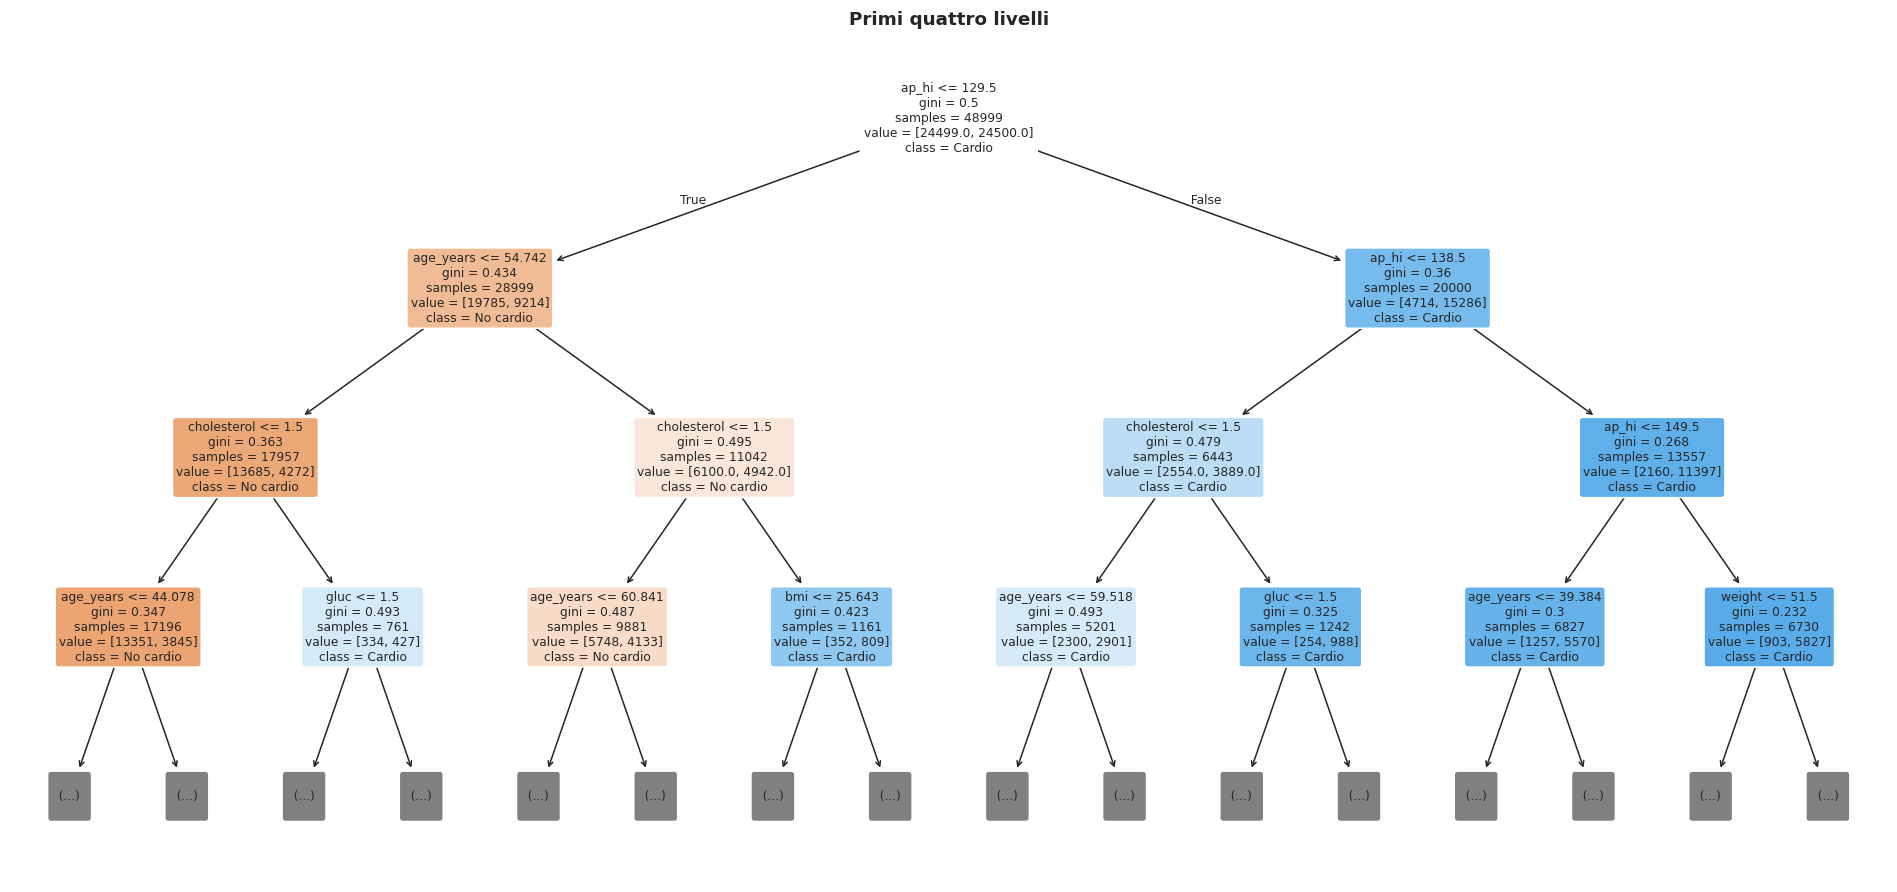

In [28]:
baseline_tree = baseline_tree_pipeline.named_steps["classifier"]

display(pd.Series({
    "profondità": baseline_tree.get_depth(),
    "numero_nodi": baseline_tree.tree_.node_count,
    "numero_foglie": baseline_tree.get_n_leaves(),
}, name="Decision Tree baseline").to_frame())

baseline_feature_names = (
    baseline_tree_pipeline.named_steps["preprocessing"]
    .named_steps["columns"]
    .get_feature_names_out()
)

plt.figure(figsize=(22, 10))
plot_tree(
    baseline_tree,
    max_depth=3,
    feature_names=baseline_feature_names,
    class_names=["No cardio", "Cardio"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Primi quattro livelli")
plt.show()

### Grid Search

L'accuracy media sugli stessi cinque fold della baseline seleziona gli
iperparametri.


In [29]:
fold_rows = []
cv_seen = np.zeros(len(X_train), dtype=int)

for fold, (fit_idx, score_idx) in enumerate(tree_cv_splits, start=1):
    y_fit = y_train.iloc[fit_idx]
    y_score = y_train.iloc[score_idx]

    cv_seen[score_idx] += 1

    fold_rows.append({
        "fold": fold,
        "n_fit": len(fit_idx),
        "n_valutazione": len(score_idx),
        "cardio_1_fit": y_fit.mean(),
        "cardio_1_valutazione": y_score.mean(),
    })

display(
    pd.DataFrame(fold_rows).style.format({
        "cardio_1_fit": "{:.2%}",
        "cardio_1_valutazione": "{:.2%}",
    })
)

,fold,n_fit,n_valutazione,cardio_1_fit,cardio_1_valutazione
0,1,39200,9799,50.20%,49.20%
1,2,39198,9801,50.01%,49.98%
2,3,39198,9801,50.16%,49.38%
3,4,39200,9799,49.88%,50.47%
4,5,39200,9799,49.76%,50.96%


In [30]:
tree_param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 8, None],
    "classifier__min_samples_split": [2],
    "classifier__min_samples_leaf": [1, 20, 100],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.001],
}

tree_grid_search = GridSearchCV(
    estimator=baseline_tree_pipeline,
    param_grid=tree_param_grid,
    scoring=tree_scoring,
    refit="accuracy",
    cv=tree_cv_splits,
    n_jobs=CV_N_JOBS,
    pre_dispatch=CV_N_JOBS,
    return_train_score=True,
    error_score="raise",
    verbose=1,
)

n_tree_candidates = len(ParameterGrid(tree_param_grid))
print(
    f"Configurazioni: {n_tree_candidates}; "
    f"fit CV: {n_tree_candidates * len(tree_cv_splits)}"
)

tree_search_start = perf_counter()
tree_grid_search.fit(X_train, y_train)
tree_search_seconds = perf_counter() - tree_search_start

best_tree_pipeline = tree_grid_search.best_estimator_
best_tree = best_tree_pipeline.named_steps["classifier"]
selected_tree_name = "Decision Tree ottimizzato"

print(f"Ricerca e refit completati in {tree_search_seconds:.1f} secondi")
print("Migliori parametri:", tree_grid_search.best_params_)
print(f"Accuracy media CV: {tree_grid_search.best_score_:.6f}")

Configurazioni: 72; fit CV: 360
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Ricerca e refit completati in 183.6 secondi
Migliori parametri: {'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'entropy', 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 100, 'classifier__min_samples_split': 2}
Accuracy media CV: 0.734505


### Risultati della ricerca e confronto degli alberi


In [31]:
tree_models = {
    "Baseline non regolarizzata": baseline_tree_pipeline,
    selected_tree_name: best_tree_pipeline,
}
comparison_models = {"Dummy prior": dummy_pipeline, **tree_models}

reference_names = (
    baseline_tree_pipeline.named_steps["preprocessing"]
    .named_steps["columns"]
    .get_feature_names_out()
)

n_train = len(X_train)

for name, pipeline in tree_models.items():
    preprocessing = pipeline.named_steps["preprocessing"]
    classifier = pipeline.named_steps["classifier"]

    feature_names = (
        preprocessing.named_steps["columns"].get_feature_names_out()
    )
    transformed = preprocessing.transform(X_train)

    np.testing.assert_array_equal(
        feature_names, reference_names,
        err_msg=f"{name}: feature diverse dalla baseline",
    )

In [32]:
tree_cv_results = pd.DataFrame(tree_grid_search.cv_results_)
tree_cv_results["gap_accuracy"] = (
    tree_cv_results["mean_train_accuracy"]
    - tree_cv_results["mean_test_accuracy"]
)

def summarize_grid_candidate(candidate_index):
    candidate = tree_cv_results.loc[candidate_index]
    rows = []

    for metric in tree_scoring:
        fold_scores = np.array([
            tree_grid_search.cv_results_[f"split{i}_test_{metric}"][candidate_index]
            for i in range(len(tree_cv_splits))
        ])

        rows.append({
            "metrica": metric,
            "training_media": candidate[f"mean_train_{metric}"],
            "cv_media": fold_scores.mean(),
            "cv_std": fold_scores.std(ddof=1),
        })

    return pd.DataFrame(rows).set_index("metrica")


def summarize_tree_complexity(name, pipeline):
    classifier = pipeline.named_steps["classifier"]

    return {
        "modello": name,
        "profondita": classifier.get_depth(),
        "nodi": classifier.tree_.node_count,
        "foglie": classifier.get_n_leaves(),
    }

best_tree_cv_summary = summarize_grid_candidate(tree_grid_search.best_index_)

tree_cv_comparison = pd.concat(
    {
        "Baseline non regolarizzata": baseline_cv_summary,
        selected_tree_name: best_tree_cv_summary,
    },
    names=["modello"],
)
tree_cv_comparison["gap_training_cv"] = (
    tree_cv_comparison["training_media"] - tree_cv_comparison["cv_media"]
)

display(tree_cv_comparison.style.format("{:.4f}"))

tree_complexity = pd.DataFrame([
    summarize_tree_complexity(name, pipeline)
    for name, pipeline in tree_models.items()
]).set_index("modello")

display(tree_complexity)

,profondita,nodi,foglie
modello,,,
Baseline non regolarizzata,49,25519,12760
Decision Tree ottimizzato,8,235,118


### Complessità e capacità di generalizzazione

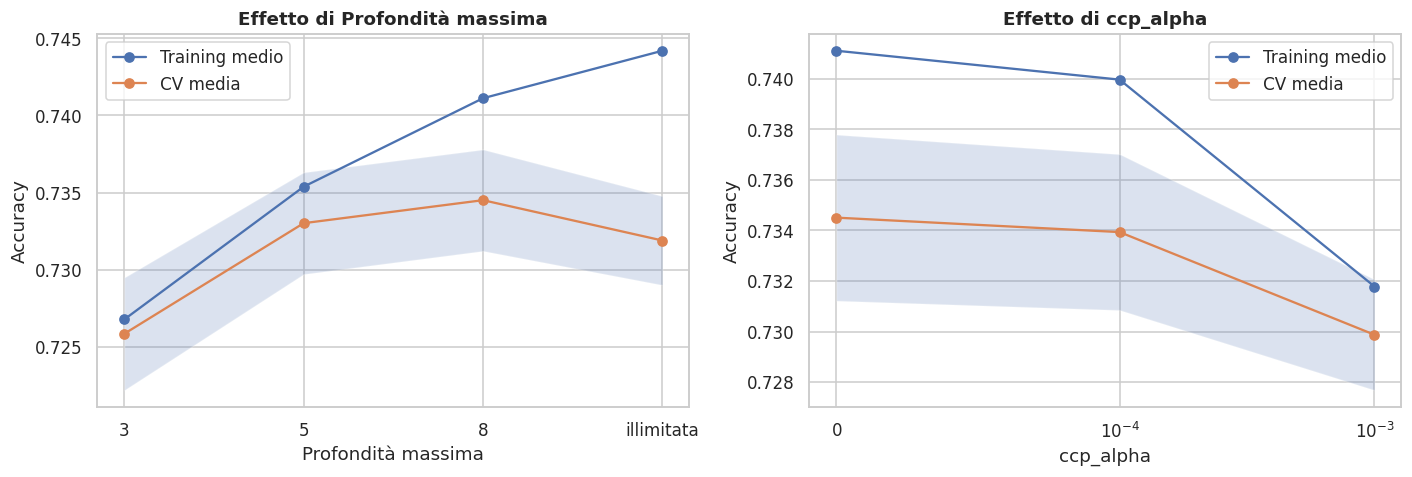

In [33]:
def filter_grid_results(results, best_params, varied):
    keep = np.ones(len(results), dtype=bool)

    for parameter, selected in best_params.items():
        if parameter != varied:
            keep &= np.array([
                params[parameter] == selected
                for params in results["params"]
            ])

    return results.loc[keep].copy()


def plot_parameter_effect(ax, subset, varied, label):
    values = [params[varied] for params in subset["params"]]

    if varied.endswith("max_depth"):
        x = np.arange(len(subset))
        ax.set_xticks(
            x,
            ["illimitata" if value is None else str(value) for value in values],
        )
    else:
        x = np.asarray(values, dtype=float)
        ax.set_xscale("symlog", linthresh=0.0001)

    train_scores = subset["mean_train_accuracy"].to_numpy()
    cv_scores = subset["mean_test_accuracy"].to_numpy()
    cv_std = subset["std_test_accuracy"].to_numpy()

    ax.plot(x, train_scores, "o-", label="Training medio")
    ax.plot(x, cv_scores, "o-", label="CV media")
    ax.fill_between(
        x, cv_scores - cv_std, cv_scores + cv_std, alpha=0.2
    )
    ax.set(xlabel=label, ylabel="Accuracy", title=f"Effetto di {label}")
    ax.legend()


parameters_to_plot = [
    ("classifier__max_depth", "Profondità massima"),
    ("classifier__ccp_alpha", "ccp_alpha"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (varied, label) in zip(axes, parameters_to_plot):
    subset = filter_grid_results(
        tree_cv_results, tree_grid_search.best_params_, varied
    )
    plot_parameter_effect(ax, subset, varied, label)

plt.tight_layout()
plt.show()

### Valutazione su training e validation


In [34]:
evaluation_splits = [
    (X_train, y_train, "training"),
    (X_validation, y_validation, "validation"),
]

model_result_rows = []

for model_name, model in comparison_models.items():
    for X_data, y_data, split_name in evaluation_splits:
        row = evaluate_classifier(
            model, model_name, X_data, y_data, split_name
        )
        row["modello_finale"] = model_name == selected_tree_name
        model_result_rows.append(row)

tree_standard_results = pd.DataFrame(model_result_rows)
tree_validation_results = (
    tree_standard_results
    .query("insieme == 'validation'")
    .set_index("modello")
)

for table, caption in [
    (tree_standard_results, "Dummy, baseline e albero ottimizzato"),
    (tree_validation_results, "Confronto sulla validation"),
]:
    display(table.style.format(precision=4).set_caption(caption))

tree_validation_predictions = {
    name: model.predict(X_validation)
    for name, model in comparison_models.items()
}
tree_validation_prediction = tree_validation_predictions[selected_tree_name]

,modello,insieme,accuracy,balanced_accuracy,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi,modello_finale
0,Dummy prior,training,0.5000,0.5000,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.2500,0,24499,False
1,Dummy prior,validation,0.4956,0.5000,0.4956,1.0000,0.0000,0.6628,0.5000,0.4956,0.2500,0,5296,False
2,Baseline non regolarizzata,training,0.9998,0.9998,1.0000,0.9996,1.0000,0.9998,1.0000,1.0000,0.0001,11,0,False
3,Baseline non regolarizzata,validation,0.6318,0.6318,0.6266,0.6362,0.6275,0.6314,0.6318,0.5790,0.3682,1893,1973,False
4,Decision Tree ottimizzato,training,0.7399,0.7399,0.7642,0.6938,0.7860,0.7273,0.8073,0.7959,0.1777,7502,5244,True
5,Decision Tree ottimizzato,validation,0.7210,0.7206,0.7400,0.6739,0.7674,0.7054,0.7877,0.7650,0.1872,1697,1232,True


,insieme,accuracy,balanced_accuracy,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi,modello_finale
modello,,,,,,,,,,,,,
Dummy prior,validation,0.4956,0.5000,0.4956,1.0000,0.0000,0.6628,0.5000,0.4956,0.2500,0,5296,False
Baseline non regolarizzata,validation,0.6318,0.6318,0.6266,0.6362,0.6275,0.6314,0.6318,0.5790,0.3682,1893,1973,False
Decision Tree ottimizzato,validation,0.7210,0.7206,0.7400,0.6739,0.7674,0.7054,0.7877,0.7650,0.1872,1697,1232,True


In [35]:
def classifier_description(model):
    classifier = model.named_steps["classifier"]

    if isinstance(classifier, DecisionTreeClassifier):
        return (
            f"Profondità {classifier.get_depth()} · "
            f"{classifier.get_n_leaves()} foglie"
        )

    return "Classe maggioritaria del training"


def validate_confusion_matrix(matrix, expected_counts, results):
    assert matrix.sum() == len(y_validation)
    np.testing.assert_array_equal(matrix.sum(axis=1), expected_counts)
    assert matrix[1, 0] == results["falsi_negativi"]
    assert matrix[0, 1] == results["falsi_positivi"]

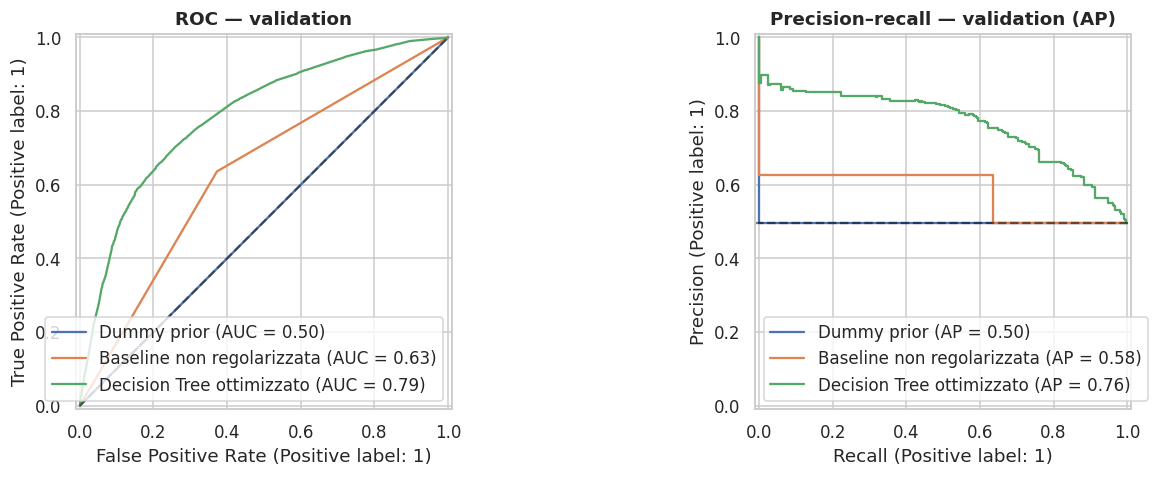

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, model in comparison_models.items():
    probability = model.predict_proba(X_validation)[:, 1]

    RocCurveDisplay.from_predictions(
        y_validation, probability, name=name, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        y_validation, probability, name=name, ax=axes[1]
    )

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].axhline(
    y_validation.mean(), color="black", ls="--", alpha=0.5
)
axes[0].set_title("ROC — validation")
axes[1].set_title("Precision–recall — validation (AP)")

plt.tight_layout()
plt.show()

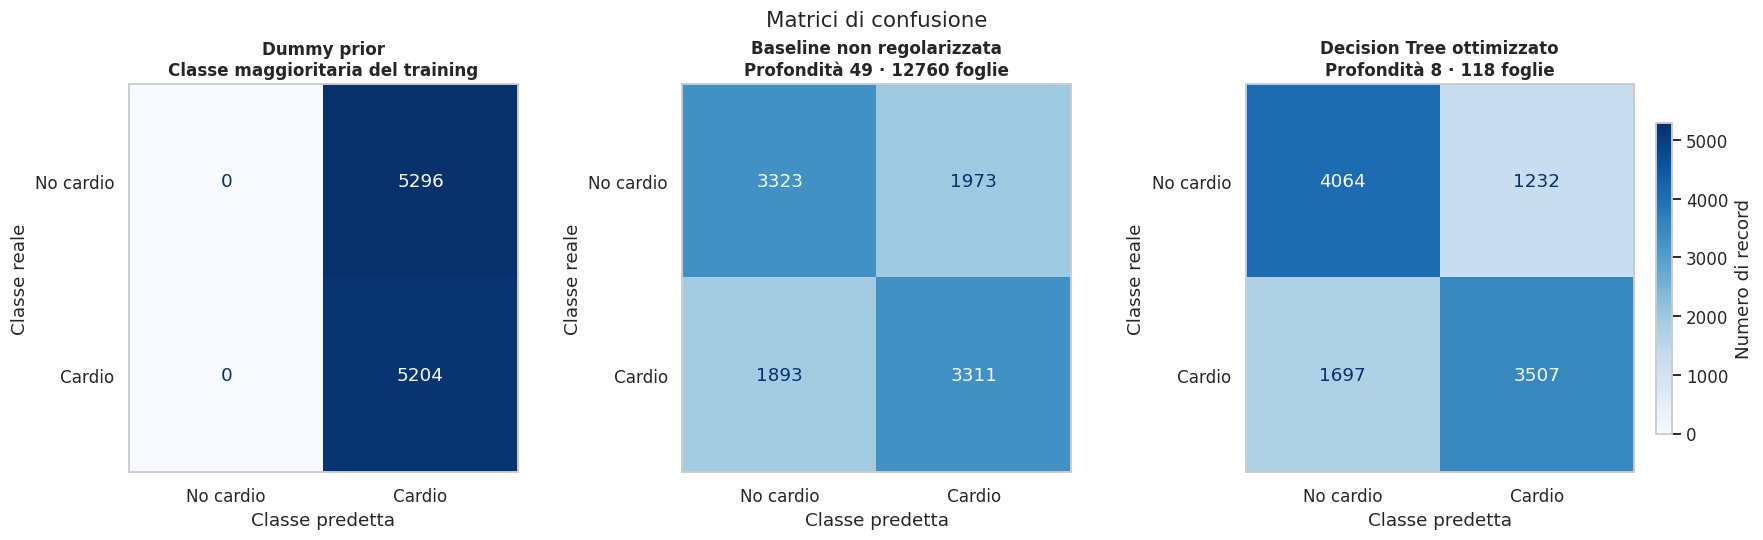


Dummy prior — classification report sulla validation:
              precision    recall  f1-score   support

   No cardio     0.0000    0.0000    0.0000      5296
      Cardio     0.4956    1.0000    0.6628      5204

    accuracy                         0.4956     10500
   macro avg     0.2478    0.5000    0.3314     10500
weighted avg     0.2456    0.4956    0.3285     10500


Baseline non regolarizzata — classification report sulla validation:
              precision    recall  f1-score   support

   No cardio     0.6371    0.6275    0.6322      5296
      Cardio     0.6266    0.6362    0.6314      5204

    accuracy                         0.6318     10500
   macro avg     0.6318    0.6318    0.6318     10500
weighted avg     0.6319    0.6318    0.6318     10500


Decision Tree ottimizzato — classification report sulla validation:
              precision    recall  f1-score   support

   No cardio     0.7054    0.7674    0.7351      5296
      Cardio     0.7400    0.6739    0.7054

In [37]:
class_labels = [0, 1]
class_names = ["No cardio", "Cardio"]

tree_confusion_matrices = {
    name: confusion_matrix(y_validation, prediction, labels=class_labels)
    for name, prediction in tree_validation_predictions.items()
}

expected_counts = [
    (y_validation == label).sum()
    for label in class_labels
]

for name, matrix in tree_confusion_matrices.items():
    validate_confusion_matrix(
        matrix, expected_counts, tree_validation_results.loc[name]
    )

color_max = max(
    matrix.max() for matrix in tree_confusion_matrices.values()
)

fig, axes = plt.subplots(
    1, 3, figsize=(16, 4.8), layout="constrained"
)

for ax, (name, matrix) in zip(axes, tree_confusion_matrices.items()):
    matrix_display = ConfusionMatrixDisplay(
        matrix, display_labels=class_names
    )
    matrix_display.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d",
        im_kw={"vmin": 0, "vmax": color_max},
    )

    description = classifier_description(comparison_models[name])
    ax.grid(False)
    ax.set_title(f"{name}\n{description}", fontsize=11)
    ax.set(xlabel="Classe predetta", ylabel="Classe reale")

fig.colorbar(matrix_display.im_, shrink=0.8, label="Numero di record")
fig.suptitle("Matrici di confusione", fontsize=14)
plt.show()

for name, prediction in tree_validation_predictions.items():
    print(f"\n{name} — classification report sulla validation:")
    print(classification_report(
        y_validation,
        prediction,
        labels=class_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

,importanza
ap_hi,0.7323
age_years,0.1381
cholesterol,0.0710
bmi,0.0237
weight,0.0097
gluc,0.0075
active,0.0071
ap_lo,0.0042
smoke,0.0025
height,0.0025


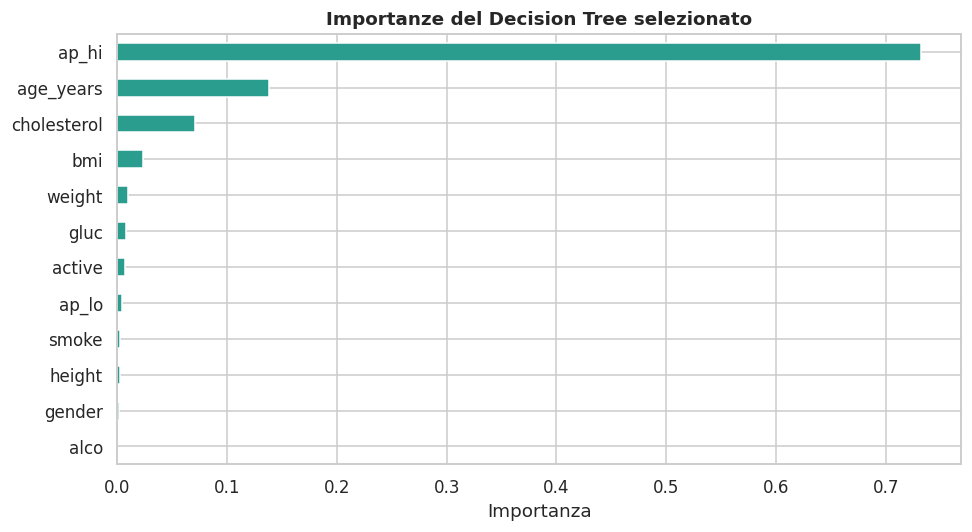

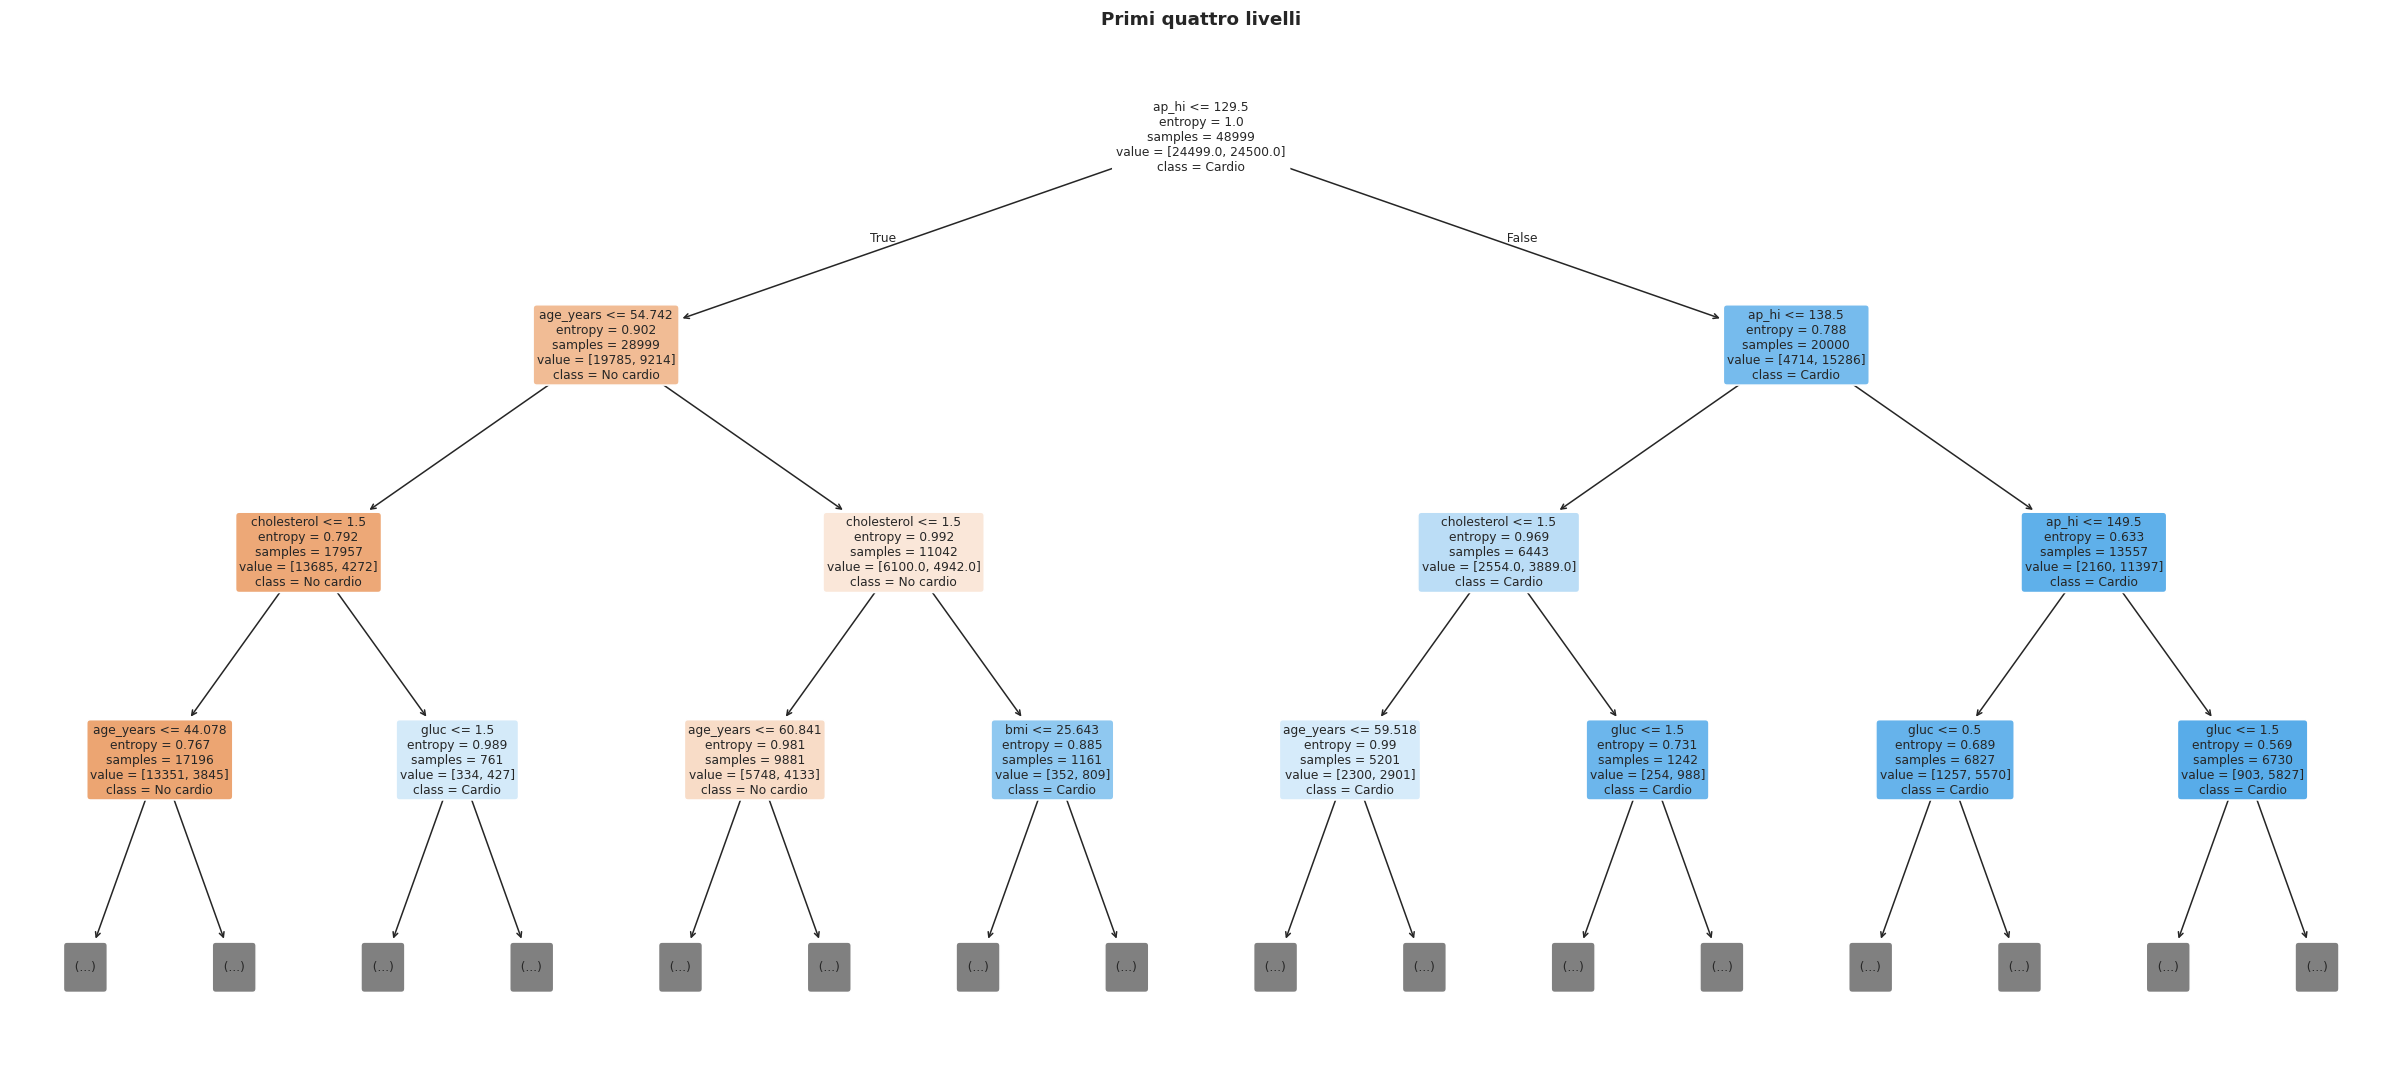

In [38]:
best_tree_feature_names = (
    best_tree_pipeline.named_steps["preprocessing"]
    .named_steps["columns"]
    .get_feature_names_out()
)

tree_importances = pd.Series(
    best_tree.feature_importances_,
    index=best_tree_feature_names,
    name="importanza",
).sort_values(ascending=False)

display(tree_importances.to_frame().style.format("{:.4f}"))

tree_importances.head(12).sort_values().plot.barh(
    figsize=(9, 5), color=ACCENT
)
plt.title("Importanze del Decision Tree selezionato")
plt.xlabel("Importanza")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_tree,
    max_depth=3,
    feature_names=best_tree_feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Primi quattro livelli")
plt.tight_layout()
plt.show()

ap_hi_importance = float(tree_importances.loc["ap_hi"])
root_feature = best_tree_feature_names[best_tree.tree_.feature[0]]
root_split = float(best_tree.tree_.threshold[0])

## Rete neurale

In [39]:
NN_MAX_EPOCHS = 100
NN_PATIENCE = 12
NN_BATCH_SIZE = 128
NN_THRESHOLD = 0.5

nn_baseline_params = {
    "hidden_units": (16,),
    "dropout_rate": 0.0,
    "l2_strength": 0.0,
    "learning_rate": 1e-3,
}

def build_nn(n_features, params, seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = Sequential([Input(shape=(n_features,))])

    for units in params["hidden_units"]:
        model.add(Dense(
            units,
            activation="relu",
            kernel_regularizer=(
                l2(params["l2_strength"]) if params["l2_strength"] > 0 else None
            ),
        ))
        if params["dropout_rate"] > 0:
            model.add(Dropout(params["dropout_rate"]))

    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="roc_auc"),
        ],
    )
    return model


def nn_dataset(X, y=None, training=False, seed=RANDOM_STATE):
    X = np.asarray(X, dtype=np.float32)
    data = X

    if y is not None:
        data = (X, np.asarray(y, dtype=np.float32).reshape(-1, 1))

    dataset = tf.data.Dataset.from_tensor_slices(data)

    if training:
        dataset = dataset.shuffle(
            len(X), seed=seed, reshuffle_each_iteration=True
        )

    options = tf.data.Options()
    options.threading.private_threadpool_size = 1
    options.threading.max_intra_op_parallelism = 1

    return (
        dataset
        .batch(NN_BATCH_SIZE)
        .with_options(options)
        .prefetch(1)
    )


def nn_probability(model, X):
    probability = model.predict(nn_dataset(X), verbose=0).ravel()
    assert np.isfinite(probability).all()
    return probability

### Preparazione e addestramento

In [40]:
def make_nn_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=NN_PATIENCE,
            min_delta=0.0,
            restore_best_weights=True,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=4,
            min_delta=1e-4,
            min_lr=1e-5,
        ),
    ]


def prepare_nn_data(X, y, groups, seed):
    split = GroupShuffleSplit(
        n_splits=1, test_size=0.15, random_state=seed
    )
    fit_idx, stop_idx = next(split.split(X, y, groups))
    assert set(groups.iloc[fit_idx]).isdisjoint(groups.iloc[stop_idx])

    preprocessor = make_preprocessor(scale_numeric=True)
    X_fit = preprocessor.fit_transform(
        X.iloc[fit_idx], y.iloc[fit_idx]
    ).astype(np.float32)
    X_stop = preprocessor.transform(X.iloc[stop_idx]).astype(np.float32)
    assert np.isfinite(X_fit).all() and np.isfinite(X_stop).all()

    return {
        "preprocessor": preprocessor,
        "fit_idx": fit_idx,
        "stop_idx": stop_idx,
        "X_fit": X_fit,
        "X_stop": X_stop,
        "y_fit": y.iloc[fit_idx],
        "y_stop": y.iloc[stop_idx],
    }


def fit_nn(params, data, seed, verbose=1):
    start = perf_counter()
    model = build_nn(data["X_fit"].shape[1], params, seed)
    history = model.fit(
        nn_dataset(data["X_fit"], data["y_fit"], training=True, seed=seed),
        validation_data=nn_dataset(data["X_stop"], data["y_stop"]),
        epochs=NN_MAX_EPOCHS,
        callbacks=make_nn_callbacks(),
        shuffle=False,
        verbose=verbose,
    ).history

    return {
        "model": model,
        "preprocessor": data["preprocessor"],
        "params": params.copy(),
        "history": history,
        "epochs": int(np.argmin(history["val_loss"]) + 1),
        "epochs_run": len(history["loss"]),
        "fit_seconds": perf_counter() - start,
        "threshold": NN_THRESHOLD,
        "test_evaluated": False,
        "n_fit": len(data["y_fit"]),
        "n_early_stopping": len(data["y_stop"]),
    }

### Baseline

In [41]:
nn_development_data = prepare_nn_data(
    X_train, y_train, groups_train, RANDOM_STATE
)
nn_fit_idx = nn_development_data["fit_idx"]
nn_stop_idx = nn_development_data["stop_idx"]
y_nn_fit = nn_development_data["y_fit"]
y_nn_stop = nn_development_data["y_stop"]

nn_baseline_name = "Rete neurale baseline"
nn_baseline_artifacts = fit_nn(
    nn_baseline_params, nn_development_data, RANDOM_STATE
)
nn_baseline_artifacts["model"].summary()

summary_fields = {
    "record_fit": "n_fit",
    "record_early_stopping": "n_early_stopping",
    "epoche_eseguite": "epochs_run",
    "epoca_pesi_ripristinati": "epochs",
    "secondi": "fit_seconds",
}
display(pd.DataFrame([{
    label: nn_baseline_artifacts[key]
    for label, key in summary_fields.items()
}]))

Epoch 1/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6916 - loss: 0.5901 - roc_auc: 0.7571 - val_accuracy: 0.7314 - val_loss: 0.5587 - val_roc_auc: 0.7902 - learning_rate: 0.0010
Epoch 2/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7299 - loss: 0.5535 - roc_auc: 0.7945 - val_accuracy: 0.7353 - val_loss: 0.5526 - val_roc_auc: 0.7961 - learning_rate: 0.0010
Epoch 3/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7318 - loss: 0.5494 - roc_auc: 0.7978 - val_accuracy: 0.7344 - val_loss: 0.5516 - val_roc_auc: 0.7975 - learning_rate: 0.0010
Epoch 4/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7338 - loss: 0.5475 - roc_auc: 0.7993 - val_accuracy: 0.7374 - val_loss: 0.5495 - val_roc_auc: 0.7980 - learning_rate: 0.0010
Epoch 5/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7341 - loss: 0.5461 - roc_auc: 0.8002 - val_accuracy: 0.7387 - val_loss: 0.5486 - val_roc_auc: 0.7988 - learning_rate: 0.0010
Epoch 6/100
326/326 ━━━━━━━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 869 (3.40 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 580 (2.27 KB)

,record_fit,record_early_stopping,epoche_eseguite,epoca_pesi_ripristinati,secondi
0,41647,7352,61,49,53.120


### Ricerca Iperparametri

In [42]:
nn_param_grid = [
    {
        "hidden_units": [(16,)],
        "dropout_rate": [0.0],
        "l2_strength": [0.0],
        "learning_rate": [1e-3],
    },
    {
        "hidden_units": [(32, 16), (64, 32)],
        "dropout_rate": [0.0, 0.2],
        "l2_strength": [1e-4],
        "learning_rate": [1e-3, 3e-4],
    },
]

nn_candidates = list(ParameterGrid(nn_param_grid))
# A parità di accuracy media, si mantiene la baseline se è tra i migliori.
nn_candidates = [nn_baseline_params.copy()] + [
    params for params in nn_candidates if params != nn_baseline_params
]
nn_cv_splits = tree_cv_splits
nn_cv_data = []
nn_fold_rows = []

for fold, (fit_idx, score_idx) in enumerate(nn_cv_splits, start=1):
    assert set(groups_train.iloc[fit_idx]).isdisjoint(
        groups_train.iloc[score_idx]
    )
    data = prepare_nn_data(
        X_train.iloc[fit_idx],
        y_train.iloc[fit_idx],
        groups_train.iloc[fit_idx],
        RANDOM_STATE + fold,
    )
    data["X_score"] = data["preprocessor"].transform(
        X_train.iloc[score_idx]
    ).astype(np.float32)
    data["y_score"] = y_train.iloc[score_idx]
    assert np.isfinite(data["X_score"]).all()
    nn_cv_data.append(data)
    nn_fold_rows.append({
        "fold": fold,
        "n_fit": len(data["y_fit"]),
        "n_early_stopping": len(data["y_stop"]),
        "n_valutazione": len(data["y_score"]),
        "cardio_1_fit": data["y_fit"].mean(),
        "cardio_1_valutazione": data["y_score"].mean(),
    })

display(pd.DataFrame(nn_fold_rows).style.format({
    "cardio_1_fit": "{:.2%}", "cardio_1_valutazione": "{:.2%}",
}))
print(
    f"Configurazioni: {len(nn_candidates)}; "
    f"fit CV: {len(nn_candidates) * len(nn_cv_splits)}"
)

,fold,n_fit,n_early_stopping,n_valutazione,cardio_1_fit,cardio_1_valutazione
0,1,33321,5879,9799,50.06%,49.20%
1,2,33319,5879,9801,50.04%,49.98%
2,3,33318,5880,9801,50.26%,49.38%
3,4,33320,5880,9799,49.83%,50.47%
4,5,33320,5880,9799,49.69%,50.96%


Configurazioni: 9; fit CV: 45


In [43]:
nn_scoring = [
    "accuracy", "balanced_accuracy", "precision", "recall_sensibilita",
    "specificita", "f1", "roc_auc", "average_precision", "brier",
]
nn_fold_results = []
nn_search_start = perf_counter()

for candidate_index, params in enumerate(nn_candidates):
    print(f"Configurazione {candidate_index + 1}/{len(nn_candidates)}: {params}")

    for fold, data in enumerate(nn_cv_data, start=1):
        artifacts = fit_nn(params, data, RANDOM_STATE + fold, verbose=0)
        row = {
            "candidato": candidate_index,
            "fold": fold,
            "epoche": artifacts["epochs_run"],
            "epoca_migliore": artifacts["epochs"],
            "secondi": artifacts["fit_seconds"],
        }

        for split_name in ["fit", "score"]:
            probability = nn_probability(
                artifacts["model"], data[f"X_{split_name}"]
            )
            metrics = classification_metrics(
                "Rete neurale", split_name, data[f"y_{split_name}"],
                (probability > NN_THRESHOLD).astype(int), probability,
            )
            row.update({
                f"{split_name}_{metric}": metrics[metric]
                for metric in nn_scoring
            })

        nn_fold_results.append(row)
        print(f"  Fold {fold}: accuracy = {row['score_accuracy']:.4f}")
        del artifacts
        tf.keras.backend.clear_session()
        gc.collect()

nn_search_seconds = perf_counter() - nn_search_start
nn_fold_results = pd.DataFrame(nn_fold_results)
nn_candidate_rows = []

for candidate_index, params in enumerate(nn_candidates):
    scores = nn_fold_results.query("candidato == @candidate_index")
    row = {"candidato": candidate_index, "params": params.copy(), **params}
    for metric in nn_scoring:
        row[f"mean_fit_{metric}"] = scores[f"fit_{metric}"].mean()
        row[f"mean_test_{metric}"] = scores[f"score_{metric}"].mean()
        row[f"std_test_{metric}"] = scores[f"score_{metric}"].std(ddof=1)
    row["epoche_medie"] = scores["epoche"].mean()
    nn_candidate_rows.append(row)

nn_cv_results = pd.DataFrame(nn_candidate_rows).set_index("candidato")
nn_best_index = int(nn_cv_results["mean_test_accuracy"].idxmax())
nn_best_params = nn_cv_results.loc[nn_best_index, "params"].copy()
nn_cv_results["rank_accuracy"] = (
    nn_cv_results["mean_test_accuracy"].rank(method="min", ascending=False).astype(int)
)
nn_cv_results["gap_accuracy"] = (
    nn_cv_results["mean_fit_accuracy"] - nn_cv_results["mean_test_accuracy"]
)

print(f"Ricerca completata in {nn_search_seconds:.1f} secondi")
print("Migliori parametri:", nn_best_params)
print(f"Accuracy media CV: {nn_cv_results.loc[nn_best_index, 'mean_test_accuracy']:.6f}")

Configurazione 1/9: {'hidden_units': (16,), 'dropout_rate': 0.0, 'l2_strength': 0.0, 'learning_rate': 0.001}
  Fold 1: accuracy = 0.7346
  Fold 2: accuracy = 0.7385
  Fold 3: accuracy = 0.7383
  Fold 4: accuracy = 0.7326
  Fold 5: accuracy = 0.7342
Configurazione 2/9: {'dropout_rate': 0.0, 'hidden_units': (32, 16), 'l2_strength': 0.0001, 'learning_rate': 0.001}
  Fold 1: accuracy = 0.7349
  Fold 2: accuracy = 0.7388
  Fold 3: accuracy = 0.7373
  Fold 4: accuracy = 0.7330
  Fold 5: accuracy = 0.7354
Configurazione 3/9: {'dropout_rate': 0.0, 'hidden_units': (32, 16), 'l2_strength': 0.0001, 'learning_rate': 0.0003}
  Fold 1: accuracy = 0.7356
  Fold 2: accuracy = 0.7383
  Fold 3: accuracy = 0.7361
  Fold 4: accuracy = 0.7317
  Fold 5: accuracy = 0.7337
Configurazione 4/9: {'dropout_rate': 0.0, 'hidden_units': (64, 32), 'l2_strength': 0.0001, 'learning_rate': 0.001}
  Fold 1: accuracy = 0.7351
  Fold 2: accuracy = 0.7358
  Fold 3: accuracy = 0.7365
  Fold 4: accuracy = 0.7362
  Fold 5: acc

### Risultati della ricerca

,rank_accuracy,hidden_units,dropout_rate,l2_strength,learning_rate,mean_fit_accuracy,mean_test_accuracy,std_test_accuracy,gap_accuracy,mean_test_roc_auc,mean_test_f1,epoche_medie
candidato,,,,,,,,,,,,
7,1,"(64, 32)",0.2000,0.0001,0.0010,0.7396,0.7365,0.0014,0.0031,0.8033,0.7253,49.6000
8,2,"(64, 32)",0.2000,0.0001,0.0003,0.7389,0.7360,0.0015,0.0028,0.8031,0.7252,76.0000
1,3,"(32, 16)",0.0000,0.0001,0.0010,0.7386,0.7359,0.0022,0.0028,0.8026,0.7262,32.4000
5,4,"(32, 16)",0.2000,0.0001,0.0010,0.7389,0.7357,0.0012,0.0032,0.8031,0.7240,45.0000
6,5,"(32, 16)",0.2000,0.0001,0.0003,0.7372,0.7356,0.0014,0.0016,0.8028,0.7238,81.4000
0,6,"(16,)",0.0000,0.0000,0.0010,0.7369,0.7356,0.0026,0.0013,0.8017,0.7254,46.0000
3,7,"(64, 32)",0.0000,0.0001,0.0010,0.7402,0.7354,0.0012,0.0047,0.8028,0.7253,28.8000
2,8,"(32, 16)",0.0000,0.0001,0.0003,0.7378,0.7351,0.0025,0.0027,0.8023,0.7259,77.0000
4,9,"(64, 32)",0.0000,0.0001,0.0003,0.7393,0.7350,0.0018,0.0043,0.8027,0.7251,38.4000


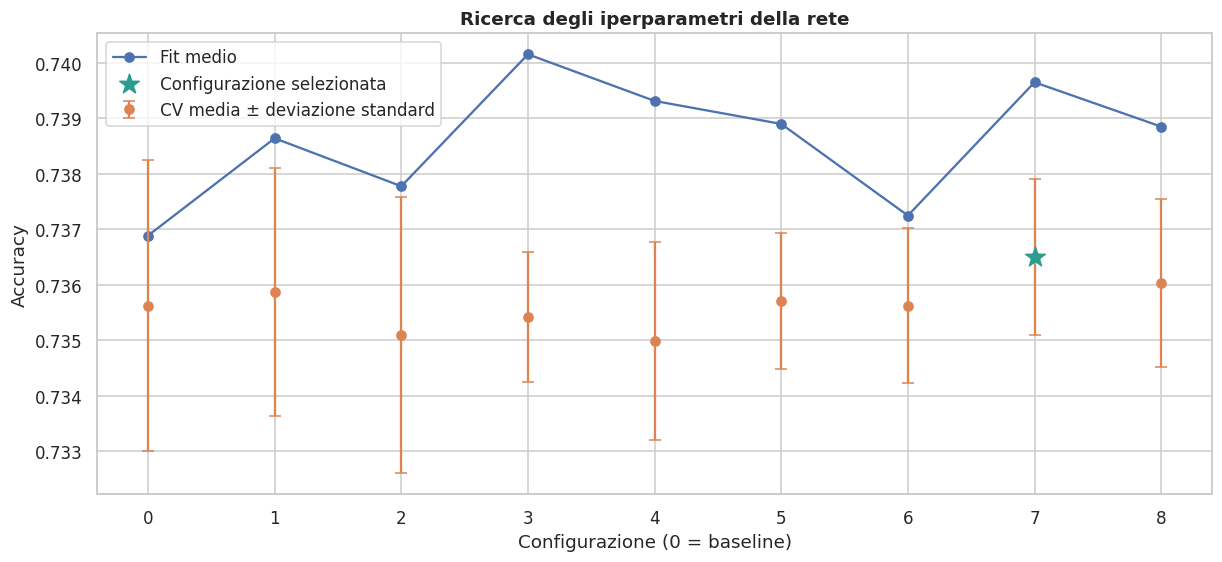

In [44]:
nn_search_columns = [
    "rank_accuracy", "hidden_units", "dropout_rate", "l2_strength", "learning_rate",
    "mean_fit_accuracy", "mean_test_accuracy", "std_test_accuracy",
    "gap_accuracy", "mean_test_roc_auc", "mean_test_f1", "epoche_medie",
]
display(
    nn_cv_results.sort_values("rank_accuracy", kind="stable")[nn_search_columns]
    .style.format(precision=4)
)

nn_cv_comparison = pd.DataFrame([
    {
        "modello": name,
        "metrica": metric,
        "fit_media": nn_cv_results.loc[index, f"mean_fit_{metric}"],
        "cv_media": nn_cv_results.loc[index, f"mean_test_{metric}"],
        "cv_std": nn_cv_results.loc[index, f"std_test_{metric}"],
    }
    for name, index in [(nn_baseline_name, 0), ("Rete neurale ottimizzata", nn_best_index)]
    for metric in nn_scoring
]).set_index(["modello", "metrica"])
display(nn_cv_comparison.style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
x = np.arange(len(nn_cv_results))
ax.plot(x, nn_cv_results["mean_fit_accuracy"], "o-", label="Fit medio")
ax.errorbar(
    x, nn_cv_results["mean_test_accuracy"],
    yerr=nn_cv_results["std_test_accuracy"],
    fmt="o", capsize=4, label="CV media ± deviazione standard",
)
ax.scatter(
    nn_best_index, nn_cv_results.loc[nn_best_index, "mean_test_accuracy"],
    marker="*", s=180, color=ACCENT, zorder=5, label="Configurazione selezionata",
)
ax.set(
    xticks=x, xlabel="Configurazione (0 = baseline)",
    ylabel="Accuracy", title="Ricerca degli iperparametri della rete",
)
ax.legend()
plt.show()

### Addestramento della rete selezionata

In [45]:
selected_nn_name = "Rete neurale ottimizzata"

if nn_best_params == nn_baseline_params:
    nn_artifacts = nn_baseline_artifacts.copy()
    print("La ricerca ha selezionato la configurazione baseline.")
else:
    nn_artifacts = fit_nn(nn_best_params, nn_development_data, RANDOM_STATE)

nn_artifacts["selection_metric"] = "accuracy"
nn_artifacts["selection_split"] = "cross-validation sul training"
nn_artifacts["cv_accuracy"] = float(nn_cv_results.loc[nn_best_index, "mean_test_accuracy"])
nn_model = nn_artifacts["model"]
nn_preprocessor = nn_artifacts["preprocessor"]
nn_params = nn_artifacts["params"]
nn_history = nn_artifacts["history"]

nn_models = {
    nn_baseline_name: nn_baseline_artifacts,
    selected_nn_name: nn_artifacts,
}

display(pd.DataFrame([
    {"modello": name, **{label: artifacts[key] for label, key in summary_fields.items()}}
    for name, artifacts in nn_models.items()
]))
nn_model.summary()

nn_preprocessing_checks = check_preprocessing(nn_preprocessor, [
    ("fit_rete", X_train.iloc[nn_fit_idx], y_nn_fit, nn_development_data["X_fit"]),
    ("early_stopping", X_train.iloc[nn_stop_idx], y_nn_stop, nn_development_data["X_stop"]),
])
display(nn_preprocessing_checks)

Epoch 1/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7157 - loss: 0.5781 - roc_auc: 0.7781 - val_accuracy: 0.7363 - val_loss: 0.5546 - val_roc_auc: 0.7982 - learning_rate: 0.0010
Epoch 2/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7302 - loss: 0.5584 - roc_auc: 0.7945 - val_accuracy: 0.7363 - val_loss: 0.5509 - val_roc_auc: 0.8014 - learning_rate: 0.0010
Epoch 3/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7332 - loss: 0.5556 - roc_auc: 0.7966 - val_accuracy: 0.7352 - val_loss: 0.5500 - val_roc_auc: 0.8019 - learning_rate: 0.0010
Epoch 4/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7335 - loss: 0.5536 - roc_auc: 0.7975 - val_accuracy: 0.7388 - val_loss: 0.5470 - val_roc_auc: 0.8021 - learning_rate: 0.0010
Epoch 5/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7340 - loss: 0.5526 - roc_auc: 0.7978 - val_accuracy: 0.7399 - val_loss: 0.5455 - val_roc_auc: 0.8030 - learning_rate: 0.0010
Epoch 6/100
326/326 ━━━━━━━━━━━━━━━

,modello,record_fit,record_early_stopping,epoche_eseguite,epoca_pesi_ripristinati,secondi
0,Rete neurale baseline,41647,7352,61,49,53.120
1,Rete neurale ottimizzata,41647,7352,45,33,49.263


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,605 (37.52 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,404 (25.02 KB)

,insieme,righe,feature,tutti_finiti
0,fit_rete,41647,16,True
1,early_stopping,7352,16,True


### Confronto tra baseline e rete ottimizzata


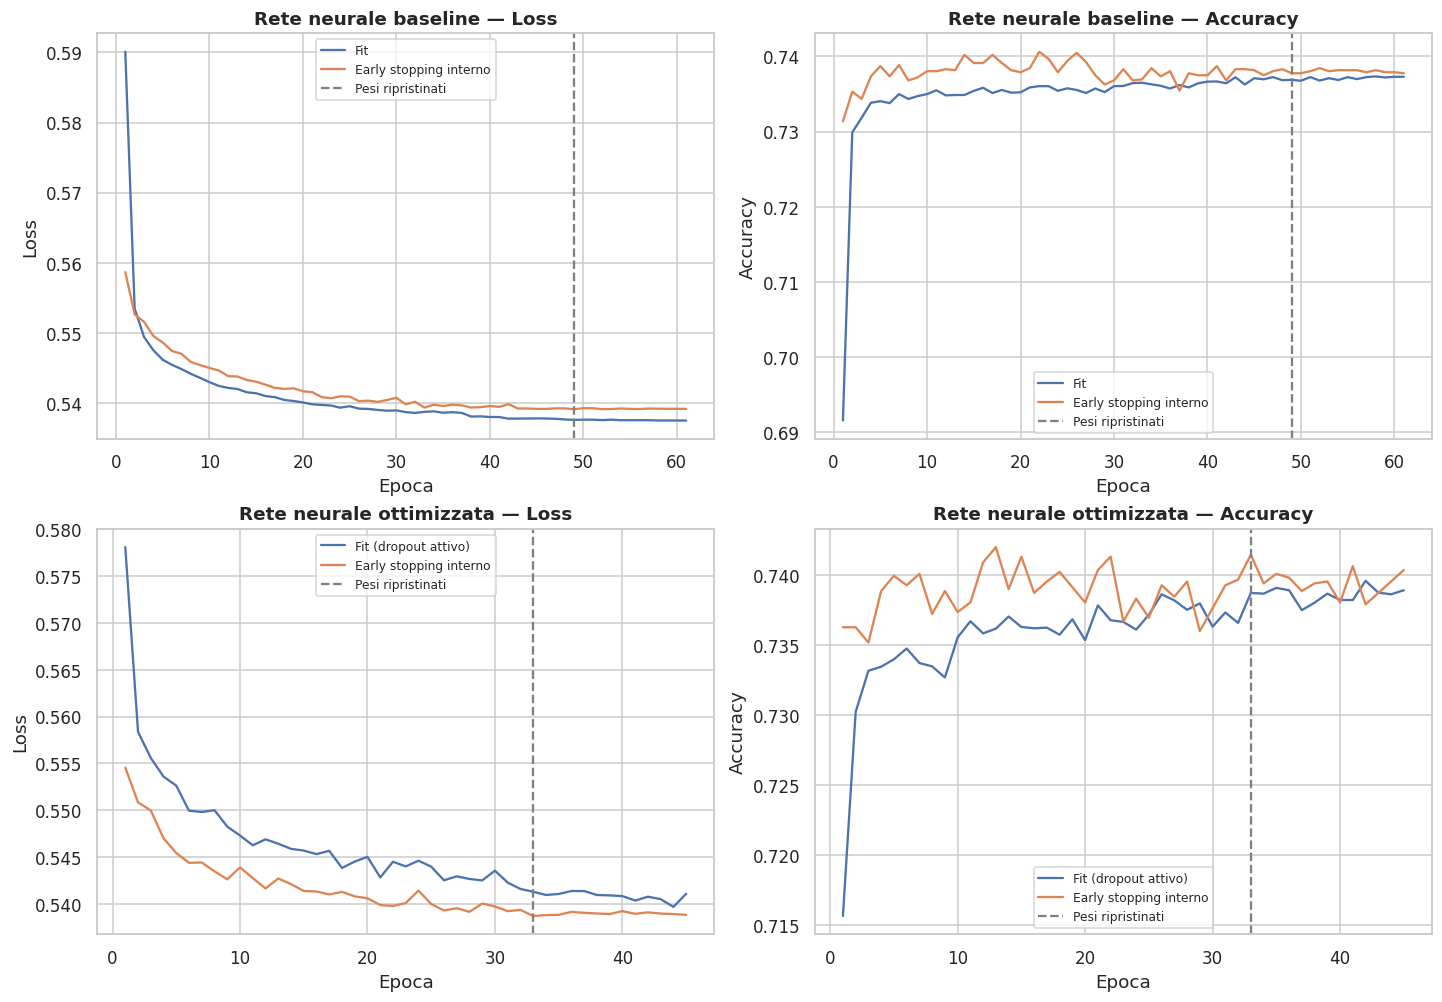

,modello,insieme,accuracy,balanced_accuracy,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi
0,Rete neurale baseline,fit_rete,0.7370,0.7371,0.7579,0.6976,0.7765,0.7265,0.8051,0.7924,0.1790,6306,4647
1,Rete neurale baseline,early_stopping,0.7378,0.7374,0.7541,0.6991,0.7758,0.7256,0.8036,0.7846,0.1794,1097,831
2,Rete neurale baseline,training,0.7371,0.7371,0.7573,0.6978,0.7764,0.7264,0.8049,0.7911,0.1791,7403,5478
3,Rete neurale baseline,validation,0.7266,0.7262,0.7439,0.6837,0.7687,0.7125,0.7923,0.7727,0.1849,1646,1225
4,Rete neurale ottimizzata,fit_rete,0.7400,0.7401,0.7645,0.6949,0.7853,0.7280,0.8083,0.7978,0.1776,6362,4465
5,Rete neurale ottimizzata,early_stopping,0.7414,0.7411,0.7621,0.6958,0.7863,0.7275,0.8054,0.7888,0.1782,1109,792
6,Rete neurale ottimizzata,training,0.7402,0.7402,0.7641,0.6951,0.7854,0.7280,0.8078,0.7964,0.1777,7471,5257
7,Rete neurale ottimizzata,validation,0.7270,0.7266,0.7467,0.6799,0.7734,0.7117,0.7924,0.7715,0.1847,1666,1200


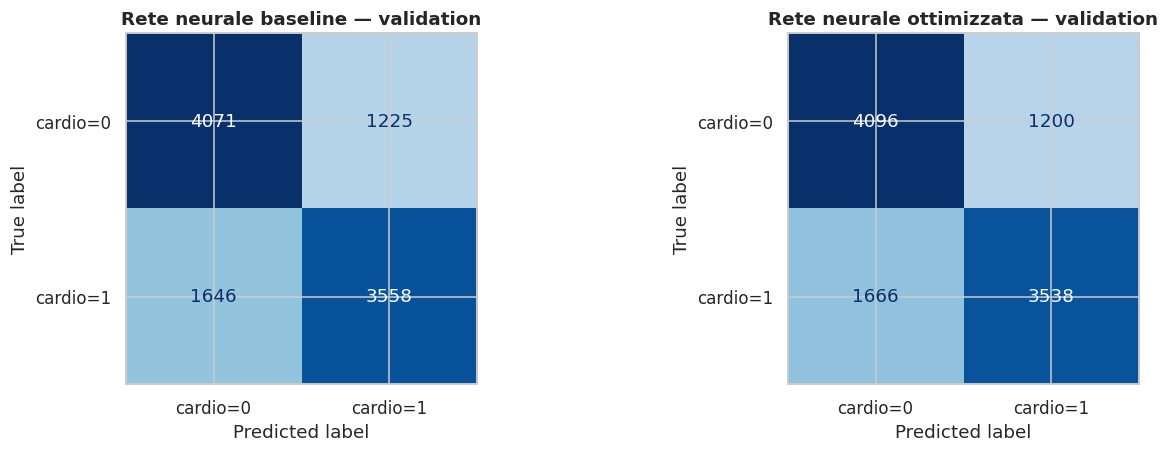

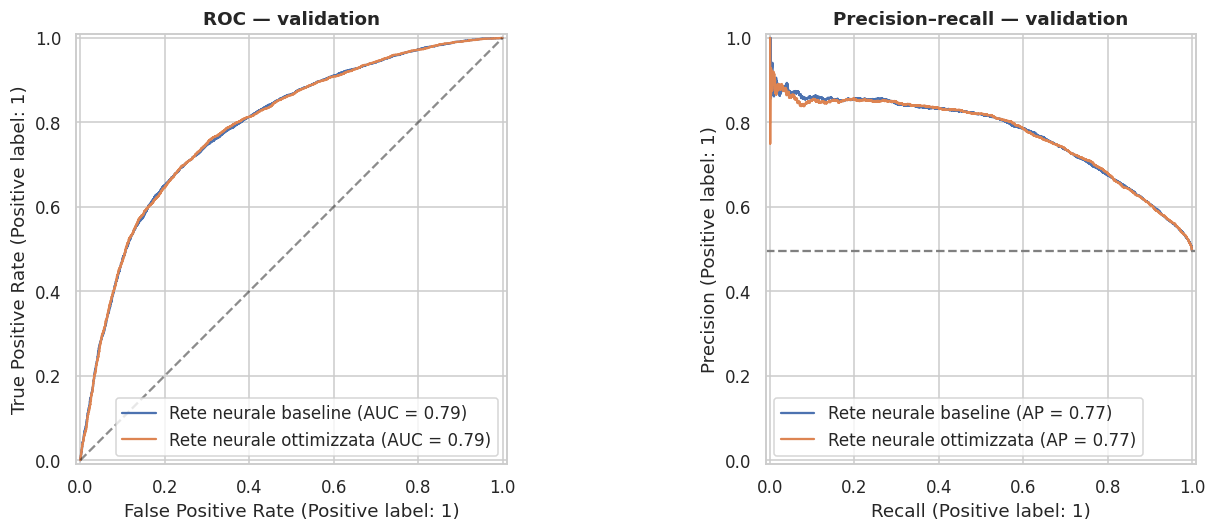

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained")
for row, (name, artifacts) in enumerate(nn_models.items()):
    history = artifacts["history"]
    epochs = np.arange(1, artifacts["epochs_run"] + 1)
    fit_label = (
        "Fit (dropout attivo)" if artifacts["params"]["dropout_rate"] > 0 else "Fit"
    )
    for column, (metric, title) in enumerate([("loss", "Loss"), ("accuracy", "Accuracy")]):
        ax = axes[row, column]
        ax.plot(epochs, history[metric], label=fit_label)
        ax.plot(epochs, history[f"val_{metric}"], label="Early stopping interno")
        ax.axvline(artifacts["epochs"], color="grey", ls="--", label="Pesi ripristinati")
        ax.set(xlabel="Epoca", ylabel=title, title=f"{name} — {title}")
        ax.legend(fontsize=8)
plt.show()

nn_evaluation_splits = [
    ("fit_rete", X_train.iloc[nn_fit_idx], y_nn_fit),
    ("early_stopping", X_train.iloc[nn_stop_idx], y_nn_stop),
    ("training", X_train, y_train),
    ("validation", X_validation, y_validation),
]
nn_result_rows = []
nn_validation_probabilities = {}

for name, artifacts in nn_models.items():
    for split_name, X_data, y_data in nn_evaluation_splits:
        probability = nn_probability(
            artifacts["model"], artifacts["preprocessor"].transform(X_data)
        )
        nn_result_rows.append(classification_metrics(
            name, split_name, y_data,
            (probability > NN_THRESHOLD).astype(int), probability,
        ))
        if split_name == "validation":
            nn_validation_probabilities[name] = probability

nn_standard_results = pd.DataFrame(nn_result_rows)
display(nn_standard_results.style.format(precision=4))
nn_validation_probability = nn_validation_probabilities[selected_nn_name]

nn_confusion_matrices = {
    name: confusion_matrix(y_validation, probability > NN_THRESHOLD, labels=[0, 1])
    for name, probability in nn_validation_probabilities.items()
}
nn_color_max = max(matrix.max() for matrix in nn_confusion_matrices.values())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, (name, matrix) in zip(axes, nn_confusion_matrices.items()):
    ConfusionMatrixDisplay(matrix, display_labels=["cardio=0", "cardio=1"]).plot(
        ax=ax, cmap="Blues", colorbar=False, im_kw={"vmin": 0, "vmax": nn_color_max},
    )
    ax.set_title(f"{name} — validation")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, probability in nn_validation_probabilities.items():
    RocCurveDisplay.from_predictions(y_validation, probability, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_validation, probability, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].axhline(y_validation.mean(), color="grey", ls="--")
axes[0].set_title("ROC — validation")
axes[1].set_title("Precision–recall — validation")
plt.tight_layout()
plt.show()

## Confronto tra i due modelli




In [47]:
comparison_model_order = [selected_tree_name, selected_nn_name]
comparison_colors = {
    selected_tree_name: "#2A6F97",
    selected_nn_name: "#D1495B",
}
comparison_columns = [
    "accuracy", "balanced_accuracy", "f1_macro", "precision",
    "recall_sensibilita", "specificita", "f1", "roc_auc",
    "average_precision", "brier", "falsi_negativi", "falsi_positivi",
]
comparison_format = {
    metric: "{:.4f}"
    for metric in comparison_columns
    if metric not in ("falsi_negativi", "falsi_positivi")
}

NN_COMPARISON_THRESHOLD = 0.5


def predict_comparison_models(X):
    probabilities = {
        selected_tree_name: best_tree_pipeline.predict_proba(X)[:, 1],
        selected_nn_name: nn_probability(
            nn_artifacts["model"],
            nn_artifacts["preprocessor"].transform(X),
        ),
    }
    predictions = {
        selected_tree_name: best_tree_pipeline.predict(X),
        selected_nn_name: (
            probabilities[selected_nn_name] > NN_COMPARISON_THRESHOLD
        ).astype(int),
    }
    return probabilities, predictions


development_splits = [
    ("training", X_train, y_train),
    ("validation", X_validation, y_validation),
]

development_rows = []

for split_name, X_data, y_data in development_splits:
    probabilities, predictions = predict_comparison_models(X_data)

    for name in comparison_model_order:
        prediction = predictions[name]

        row = classification_metrics(
            name, split_name, y_data, prediction, probabilities[name]
        )
        row["f1_macro"] = f1_score(
            y_data, prediction, average="macro", zero_division=0
        )
        development_rows.append(row)

    if split_name == "validation":
        nn_validation_probability = probabilities[selected_nn_name]

development_comparison = pd.DataFrame(development_rows)

display(
    development_comparison[["modello", "insieme"] + comparison_columns]
    .style.format(comparison_format)
)


,modello,insieme,accuracy,balanced_accuracy,f1_macro,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi
0,Decision Tree ottimizzato,training,0.7399,0.7399,0.7393,0.7642,0.6938,0.7860,0.7273,0.8073,0.7959,0.1777,7502,5244
1,Rete neurale ottimizzata,training,0.7402,0.7402,0.7397,0.7641,0.6951,0.7854,0.7280,0.8078,0.7964,0.1777,7471,5257
2,Decision Tree ottimizzato,validation,0.7210,0.7206,0.7203,0.7400,0.6739,0.7674,0.7054,0.7877,0.7650,0.1872,1697,1232
3,Rete neurale ottimizzata,validation,0.7270,0.7266,0.7263,0.7467,0.6799,0.7734,0.7117,0.7924,0.7715,0.1847,1666,1200


### Confronto principale sul test


,accuracy,balanced_accuracy,f1_macro,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi
modello,,,,,,,,,,,,
Decision Tree ottimizzato,0.7344,0.7346,0.7340,0.7573,0.6935,0.7757,0.7240,0.7991,0.7763,0.1808,1617,1172
Rete neurale ottimizzata,0.7384,0.7386,0.7381,0.7594,0.7014,0.7757,0.7293,0.8055,0.7863,0.1781,1575,1172


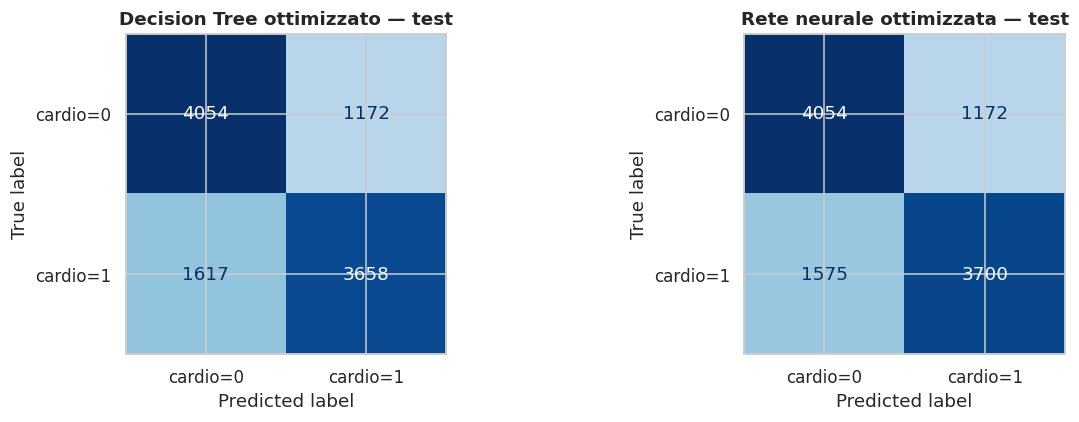

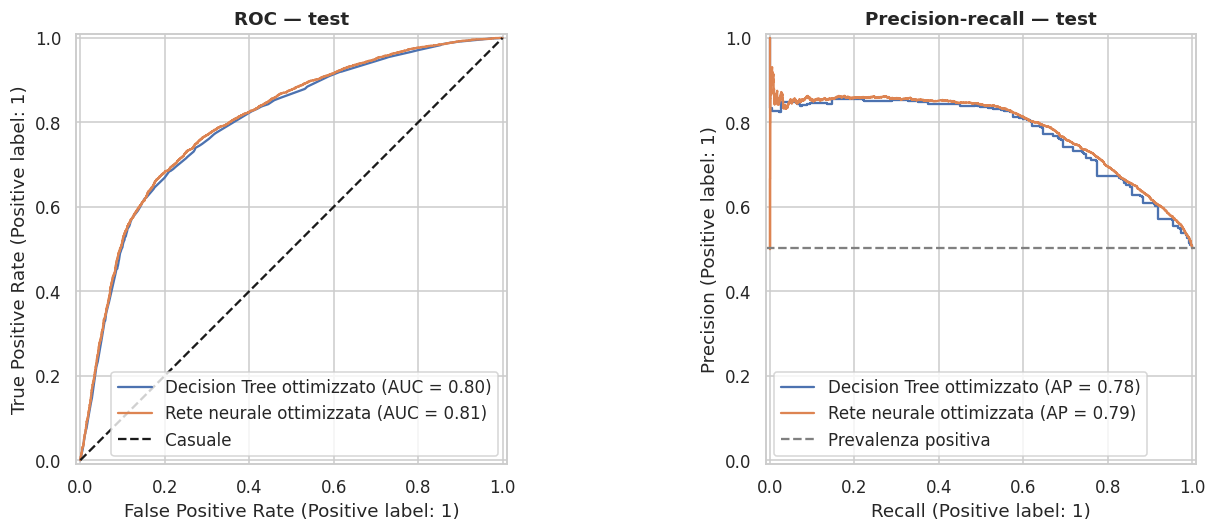

Decision Tree ottimizzato
              precision    recall  f1-score   support

           0     0.7149    0.7757    0.7441      5226
           1     0.7573    0.6935    0.7240      5275

    accuracy                         0.7344     10501
   macro avg     0.7361    0.7346    0.7340     10501
weighted avg     0.7362    0.7344    0.7340     10501

Rete neurale ottimizzata
              precision    recall  f1-score   support

           0     0.7202    0.7757    0.7469      5226
           1     0.7594    0.7014    0.7293      5275

    accuracy                         0.7384     10501
   macro avg     0.7398    0.7386    0.7381     10501
weighted avg     0.7399    0.7384    0.7381     10501



In [48]:
final_test_probabilities, final_test_predictions = (
    predict_comparison_models(X_test)
)

final_test_results = pd.DataFrame([
    classification_metrics(
        name, "test", y_test, final_test_predictions[name], probability
    )
    for name, probability in final_test_probabilities.items()
]).set_index("modello")

final_test_results["f1_macro"] = [
    f1_score(
        y_test,
        final_test_predictions[name],
        average="macro",
        zero_division=0,
    )
    for name in final_test_results.index
]

display(
    final_test_results[comparison_columns]
    .style.format(comparison_format)
)
nn_artifacts["test_evaluated"] = True

final_test_confusion_matrices = {
    name: confusion_matrix(y_test, prediction, labels=[0, 1])
    for name, prediction in final_test_predictions.items()
}
shared_max = max(
    matrix.max() for matrix in final_test_confusion_matrices.values()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, matrix) in zip(axes, final_test_confusion_matrices.items()):
    ConfusionMatrixDisplay(
        matrix,
        display_labels=["cardio=0", "cardio=1"],
    ).plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        im_kw={"vmin": 0, "vmax": shared_max},
    )
    ax.set_title(f"{name} — test")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, probability in final_test_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test, probability, name=name, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, probability, name=name, ax=axes[1]
    )

axes[0].plot([0, 1], [0, 1], "k--", label="Casuale")
axes[1].axhline(
    y_test.mean(),
    color="grey",
    linestyle="--",
    label="Prevalenza positiva",
)
axes[0].set_title("ROC — test")
axes[1].set_title("Precision-recall — test")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

for name, prediction in final_test_predictions.items():
    print(name)
    print(classification_report(
        y_test,
        prediction,
        labels=[0, 1],
        digits=4,
        zero_division=0,
    ))

### Analisi degli errori condivisi


,esito,record,percentuale
0,Entrambi corretti,7421,70.67%
1,Solo albero corretto,291,2.77%
2,Solo rete corretta,333,3.17%
3,Entrambi errati,2456,23.39%


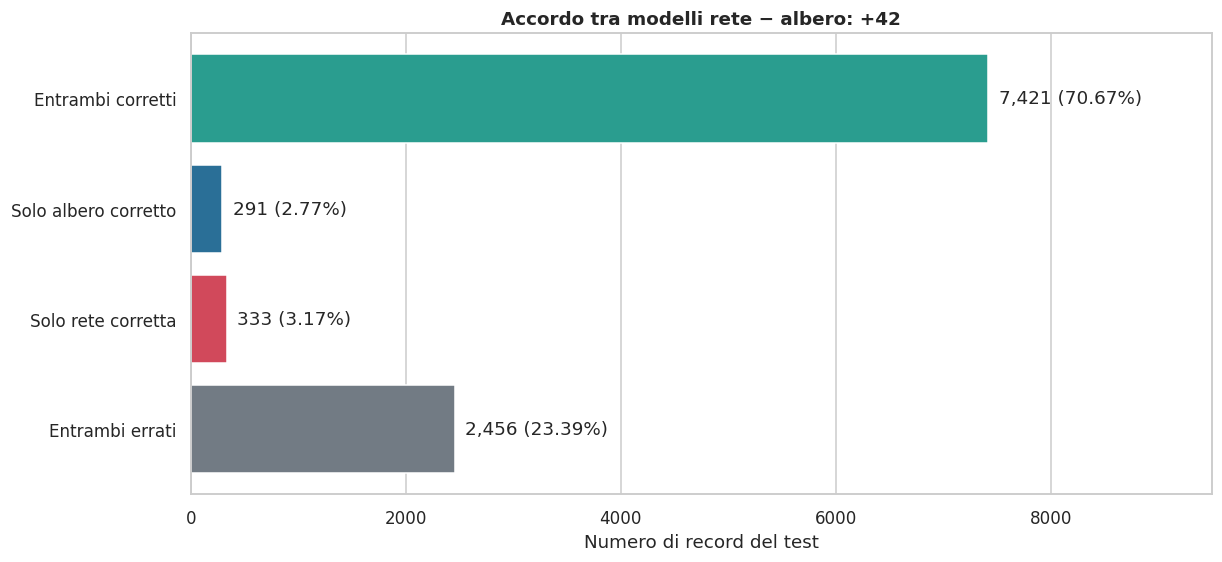

In [49]:
test_target_array = np.asarray(y_test)
tree_correct = (
    np.asarray(final_test_predictions[selected_tree_name]) == test_target_array
)
nn_correct = (
    np.asarray(final_test_predictions[selected_nn_name]) == test_target_array
)

outcome_masks = {
    "Entrambi corretti": tree_correct & nn_correct,
    "Solo albero corretto": tree_correct & ~nn_correct,
    "Solo rete corretta": ~tree_correct & nn_correct,
    "Entrambi errati": ~tree_correct & ~nn_correct,
}

error_overlap = pd.DataFrame([
    {"esito": outcome, "record": int(mask.sum())}
    for outcome, mask in outcome_masks.items()
])
error_overlap["percentuale"] = (
    error_overlap["record"] / len(y_test) * 100
)

net_correct_gain = int(nn_correct.sum() - tree_correct.sum())

display(error_overlap.style.format({"percentuale": "{:.2f}%"}))

colors = [
    "#2A9D8F",
    comparison_colors[selected_tree_name],
    comparison_colors[selected_nn_name],
    "#727B84",
]
bar_labels = [
    f"{n:,} ({pct:.2f}%)"
    for n, pct in zip(error_overlap["record"], error_overlap["percentuale"])
]

fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
bars = ax.barh(
    error_overlap["esito"], error_overlap["record"], color=colors
)
ax.bar_label(bars, labels=bar_labels, padding=7)
ax.invert_yaxis()
ax.set_xlim(0, max(1, error_overlap["record"].max()) * 1.28)
ax.set(
    xlabel="Numero di record del test",
    ylabel="",
    title=(
        "Accordo tra modelli "
        f"rete − albero: {net_correct_gain:+,}"
    ),
)
ax.grid(axis="y", visible=False)
plt.show()

## Analisi finale per diversi obiettivi di recall

Si confrontano obiettivi minimi di recall del 70%, 75%, 80%, 85%, 90%
e 95%:
Per ciascun obiettivo si cerca sulla ROC della validation la soglia di probabilità
più alta che lo raggiunge, usando `probabilità >= soglia`. A parità di obiettivo,
questa scelta limita i falsi positivi tra le soglie che soddisfano il vincolo.


,modello,accuracy_validation,record_corretti
0,Rete neurale ottimizzata,72.7048%,7634
1,Decision Tree ottimizzato,72.1048%,7571


Modello scelto sulla validation: Rete neurale ottimizzata


,regola,obiettivo_recall,soglia,recall_sensibilita,precision,specificita,accuracy,balanced_accuracy,falsi_negativi,falsi_positivi
0,"Originale (0,50)",—,0.500000,67.99%,74.67%,77.34%,72.70%,72.66%,1666,1200
1,Recall >= 70%,70%,0.478833,70.00%,73.57%,75.28%,72.67%,72.64%,1561,1309
2,Recall >= 75%,75%,0.422613,75.00%,71.13%,70.09%,72.52%,72.55%,1301,1584
3,Recall >= 80%,80%,0.363334,80.02%,67.96%,62.93%,71.40%,71.47%,1040,1963
4,Recall >= 85%,85%,0.314658,85.01%,64.20%,53.42%,69.08%,69.21%,780,2467
5,Recall >= 90%,90%,0.272436,90.01%,60.52%,42.30%,65.94%,66.15%,520,3056
6,Recall >= 95%,95%,0.212790,95.00%,56.57%,28.32%,61.37%,61.66%,260,3796


Variazioni rispetto alla regola originale sulla validation (pp = punti percentuali):


,regola,delta_recall_sensibilita_pp,delta_precision_pp,delta_specificita_pp,delta_accuracy_pp,delta_balanced_accuracy_pp,falsi_negativi_evitati,falsi_positivi_aggiuntivi
0,"Originale (0,50)",+0.00,+0.00,+0.00,+0.00,+0.00,0,0
1,Recall >= 70%,+2.02,-1.11,-2.06,-0.04,-0.02,105,109
2,Recall >= 75%,+7.01,-3.54,-7.25,-0.18,-0.12,365,384
3,Recall >= 80%,+12.03,-6.71,-14.41,-1.30,-1.19,626,763
4,Recall >= 85%,+17.03,-10.47,-23.92,-3.63,-3.45,886,1267
5,Recall >= 90%,+22.02,-14.16,-35.05,-6.76,-6.51,1146,1856
6,Recall >= 95%,+27.02,-18.11,-49.02,-11.33,-11.00,1406,2596


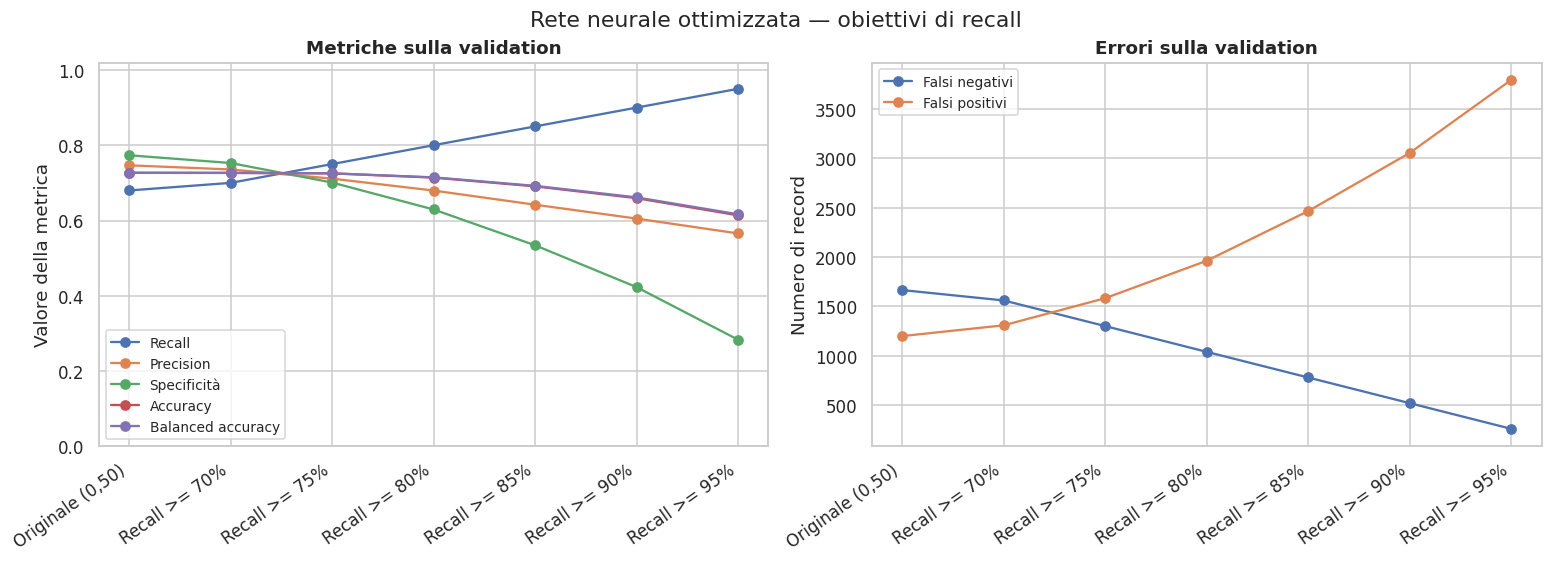

In [50]:
RECALL_TARGETS = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

threshold_validation_probabilities, threshold_validation_predictions = (
    predict_comparison_models(X_validation)
)

threshold_model_ranking = (
    pd.DataFrame([
        {
            "modello": name,
            "accuracy_validation": accuracy_score(y_validation, prediction),
            "record_corretti": int(
                np.sum(np.asarray(y_validation) == prediction)
            ),
        }
        for name, prediction in threshold_validation_predictions.items()
    ])
    .sort_values("record_corretti", ascending=False, kind="stable")
    .reset_index(drop=True)
)

threshold_selected_name = threshold_model_ranking.loc[0, "modello"]
threshold_validation_probability = np.asarray(
    threshold_validation_probabilities[threshold_selected_name],
    dtype=float,
).ravel()

display(
    threshold_model_ranking.style.format({"accuracy_validation": "{:.4%}"})
)
print("Modello scelto sulla validation:", threshold_selected_name)

validation_fpr, validation_tpr, validation_thresholds = roc_curve(
    y_validation, threshold_validation_probability, drop_intermediate=False
)

original_validation_prediction = threshold_validation_predictions[threshold_selected_name]
original_metrics = classification_metrics(
    threshold_selected_name, "validation", y_validation,
    original_validation_prediction, threshold_validation_probability,
)
original_metrics.update({
    "regola": "Originale (0,50)",
    "obiettivo_recall": np.nan,
    "soglia": NN_COMPARISON_THRESHOLD,
})
threshold_rows = [original_metrics]

for target_recall in RECALL_TARGETS:
    eligible = np.flatnonzero(
        (validation_tpr >= target_recall) & np.isfinite(validation_thresholds)
    )
    if eligible.size == 0:
        raise ValueError(f"Nessuna soglia raggiunge recall {target_recall:.0%}.")
    threshold = float(validation_thresholds[eligible[0]])
    prediction = (threshold_validation_probability >= threshold).astype(int)
    row = classification_metrics(
        threshold_selected_name, "validation", y_validation,
        prediction, threshold_validation_probability,
    )
    row.update({
        "regola": f"Recall >= {target_recall:.0%}",
        "obiettivo_recall": target_recall,
        "soglia": threshold,
    })
    threshold_rows.append(row)

threshold_validation_results = pd.DataFrame(threshold_rows)
recall_metric_labels = {
    "recall_sensibilita": "Recall",
    "precision": "Precision",
    "specificita": "Specificità",
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
}
threshold_columns = [
    "regola", "obiettivo_recall", "soglia", *recall_metric_labels,
    "falsi_negativi", "falsi_positivi",
]
threshold_format = {
    **{metric: "{:.2%}" for metric in recall_metric_labels},
    "obiettivo_recall": "{:.0%}", "soglia": "{:.6f}",
}
display(
    threshold_validation_results[threshold_columns]
    .style.format(threshold_format, na_rep="—")
)

threshold_changes = threshold_validation_results[["regola"]].copy()
for metric in recall_metric_labels:
    threshold_changes[f"delta_{metric}_pp"] = 100 * (
        threshold_validation_results[metric] - original_metrics[metric]
    )
threshold_changes["falsi_negativi_evitati"] = (
    original_metrics["falsi_negativi"] - threshold_validation_results["falsi_negativi"]
)
threshold_changes["falsi_positivi_aggiuntivi"] = (
    threshold_validation_results["falsi_positivi"] - original_metrics["falsi_positivi"]
)
print("Variazioni rispetto alla regola originale sulla validation (pp = punti percentuali):")
display(threshold_changes.style.format({
    f"delta_{metric}_pp": "{:+.2f}" for metric in recall_metric_labels
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
x = np.arange(len(threshold_validation_results))
for metric, label in recall_metric_labels.items():
    axes[0].plot(x, threshold_validation_results[metric], "o-", label=label)
for metric, label in [
    ("falsi_negativi", "Falsi negativi"),
    ("falsi_positivi", "Falsi positivi"),
]:
    axes[1].plot(x, threshold_validation_results[metric], "o-", label=label)
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(threshold_validation_results["regola"], rotation=35, ha="right")
    ax.legend(fontsize=9)
axes[0].set(ylabel="Valore della metrica", ylim=(0, 1.02), title="Metriche sulla validation")
axes[1].set(ylabel="Numero di record", title="Errori sulla validation")
fig.suptitle(f"{threshold_selected_name} — obiettivi di recall")
plt.show()


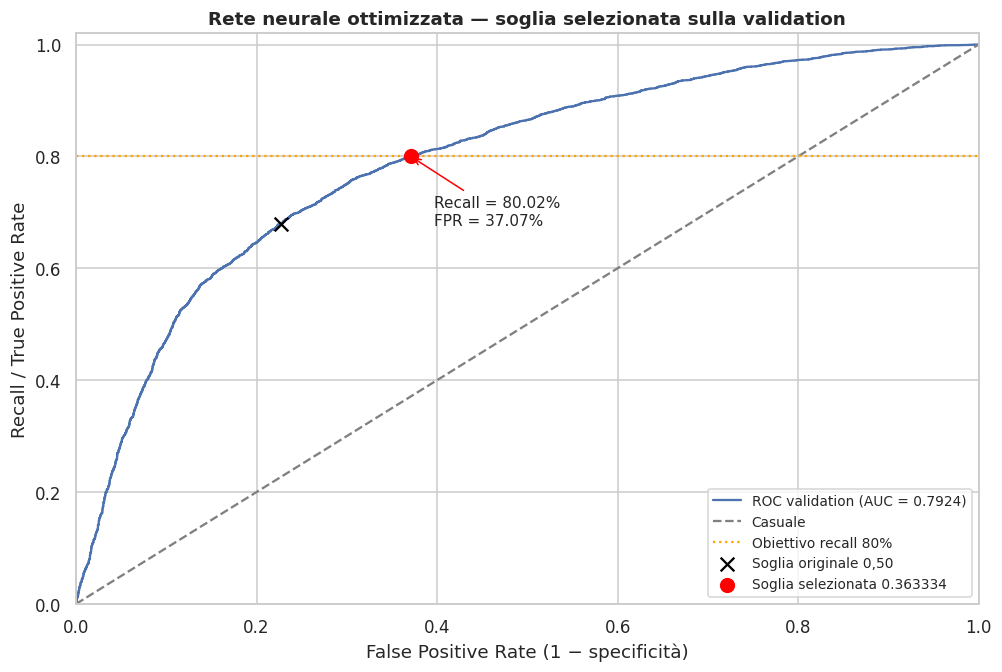

,modello,insieme,regola,accuracy,balanced_accuracy,f1_macro,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi
0,Rete neurale ottimizzata,validation,"Regola originale (0,50)",0.7270,0.7266,0.7263,0.7467,0.6799,0.7734,0.7117,0.7924,0.7715,0.1847,1666,1200
1,Rete neurale ottimizzata,validation,Recall >= 80% (soglia 0.363334),0.7140,0.7147,0.7122,0.6796,0.8002,0.6293,0.7350,0.7924,0.7715,0.1847,1040,1963
2,Rete neurale ottimizzata,test,"Regola originale (0,50)",0.7384,0.7386,0.7381,0.7594,0.7014,0.7757,0.7293,0.8055,0.7863,0.1781,1575,1172
3,Rete neurale ottimizzata,test,Recall >= 80% (soglia 0.363334),0.7199,0.7195,0.7174,0.6876,0.8108,0.6282,0.7441,0.8055,0.7863,0.1781,998,1943


Differenze sul test: metriche in valore assoluto, errori in numero di record.


,accuracy,balanced_accuracy,f1_macro,precision,recall_sensibilita,specificita,f1,roc_auc,average_precision,brier,falsi_negativi,falsi_positivi
Soglia selezionata − regola originale,-0.0185,-0.0191,-0.0207,-0.0718,0.1094,-0.1475,0.0149,0.0000,0.0000,0.0000,-577,771


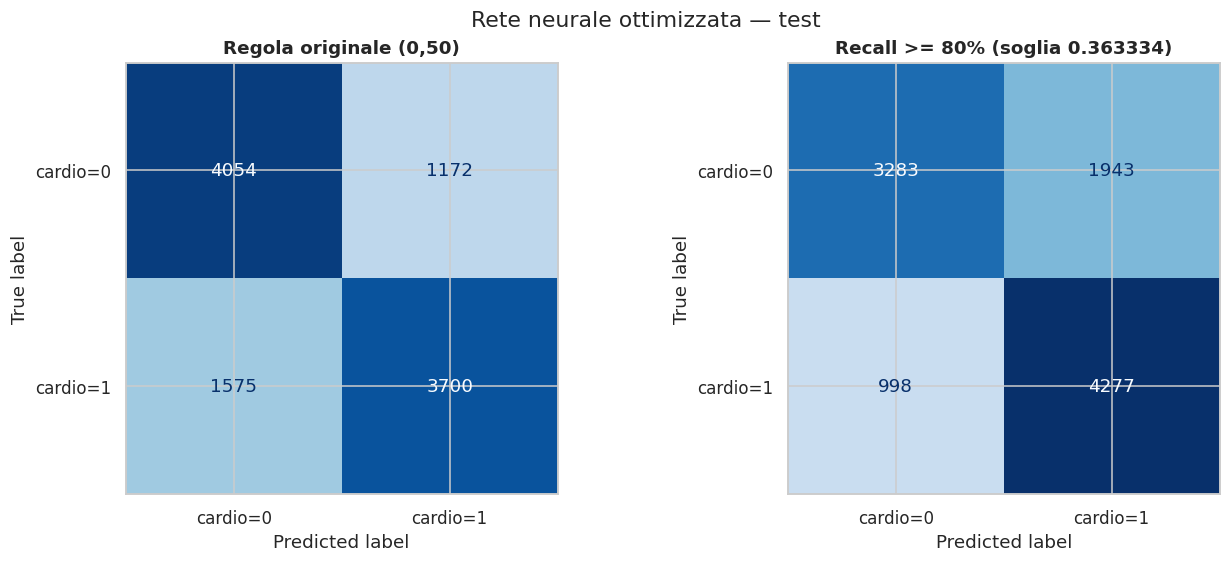

In [51]:
SELECTED_RECALL_TARGET = 0.80

if SELECTED_RECALL_TARGET not in RECALL_TARGETS:
    raise ValueError("Scegliere uno degli obiettivi presenti in RECALL_TARGETS.")
selected_row = threshold_validation_results.loc[
    threshold_validation_results["obiettivo_recall"] == SELECTED_RECALL_TARGET
].iloc[0]
selected_threshold = float(selected_row["soglia"])
selected_threshold_validation_prediction = (
    threshold_validation_probability >= selected_threshold
).astype(int)
selected_threshold_artifacts = {
    "model_name": threshold_selected_name,
    "model_selection_metric": "accuracy",
    "model_selection_split": "validation",
    "threshold_selection_split": "validation",
    "target_recall": SELECTED_RECALL_TARGET,
    "threshold": selected_threshold,
    "comparison_operator": ">=",
}

selected_validation_fpr = 1 - float(selected_row["specificita"])
selected_validation_recall = float(selected_row["recall_sensibilita"])
original_validation_fpr = 1 - original_metrics["specificita"]
original_validation_recall = original_metrics["recall_sensibilita"]
validation_auc = roc_auc_score(
    y_validation, threshold_validation_probability
)

fig, ax = plt.subplots(figsize=(9, 6), layout="constrained")
ax.plot(
    validation_fpr, validation_tpr,
    label=f"ROC validation (AUC = {validation_auc:.4f})",
)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Casuale")
ax.axhline(
    SELECTED_RECALL_TARGET, color="orange", linestyle=":",
    label=f"Obiettivo recall {SELECTED_RECALL_TARGET:.0%}",
)
ax.scatter(
    original_validation_fpr, original_validation_recall,
    color="black", marker="x", s=80, zorder=5,
    label="Soglia originale 0,50",
)
ax.scatter(
    selected_validation_fpr, selected_validation_recall,
    color="red", s=80, zorder=5,
    label=f"Soglia selezionata {selected_threshold:.6f}",
)
ax.annotate(
    f"Recall = {selected_validation_recall:.2%}\n"
    f"FPR = {selected_validation_fpr:.2%}",
    (selected_validation_fpr, selected_validation_recall),
    xytext=(15, -45), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "red"},
    fontsize=10,
)
ax.set(
    xlabel="False Positive Rate (1 − specificità)",
    ylabel="Recall / True Positive Rate",
    title=f"{threshold_selected_name} — soglia selezionata sulla validation",
    xlim=(0, 1), ylim=(0, 1.02),
)
ax.legend(loc="lower right", fontsize=9)
plt.show()

selected_threshold_test_probability = np.asarray(
    final_test_probabilities[threshold_selected_name],
    dtype=float,
).ravel()
selected_threshold_test_prediction = (
    selected_threshold_test_probability >= selected_threshold
).astype(int)

original_rule = "Regola originale (0,50)"
selected_rule = f"Recall >= {SELECTED_RECALL_TARGET:.0%} (soglia {selected_threshold:.6f})"

threshold_datasets = [
    (
        "validation",
        y_validation,
        threshold_validation_probability,
        threshold_validation_predictions[threshold_selected_name],
        selected_threshold_validation_prediction,
    ),
    (
        "test",
        y_test,
        selected_threshold_test_probability,
        final_test_predictions[threshold_selected_name],
        selected_threshold_test_prediction,
    ),
]

selected_threshold_rows = []

for split_name, target, probability, original, adjusted in threshold_datasets:
    for rule, prediction in [
        (original_rule, original),
        (selected_rule, adjusted),
    ]:
        row = classification_metrics(
            threshold_selected_name, split_name, target, prediction, probability
        )
        row["regola"] = rule
        row["f1_macro"] = f1_score(
            target, prediction, average="macro", zero_division=0
        )
        selected_threshold_rows.append(row)

selected_threshold_results = pd.DataFrame(selected_threshold_rows)

display(
    selected_threshold_results[
        ["modello", "insieme", "regola"] + comparison_columns
    ].style.format(comparison_format)
)

selected_threshold_test_rows = (
    selected_threshold_results.query("insieme == 'test'").set_index("regola")
)
threshold_test_difference = (
    selected_threshold_test_rows.loc[selected_rule, comparison_columns]
    - selected_threshold_test_rows.loc[original_rule, comparison_columns]
).to_frame().T
threshold_test_difference.index = ["Soglia selezionata − regola originale"]
print("Differenze sul test: metriche in valore assoluto, errori in numero di record.")
display(threshold_test_difference.style.format(comparison_format))

selected_test_predictions = [
    final_test_predictions[threshold_selected_name],
    selected_threshold_test_prediction,
]
selected_cm_max = max(
    confusion_matrix(y_test, prediction, labels=[0, 1]).max()
    for prediction in selected_test_predictions
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

for ax, prediction, title in zip(
    axes,
    selected_test_predictions,
    [original_rule, selected_rule],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        labels=[0, 1],
        display_labels=["cardio=0", "cardio=1"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
        im_kw={"vmin": 0, "vmax": selected_cm_max},
    )
    ax.set_title(title)

fig.suptitle(f"{threshold_selected_name} — test")
plt.show()
